# Introduction to Machine Learning -- MC886
# Assignment 3 - Neural Networks and Overparameterization

**Professor:** Marcelo da Silva Reis  
**PED:** Daniel Gardin Gratti  
**PAD:** Guilherme Henrique Ichiro Seto Ito

In [1]:
# Enter your name and RA number below.
print("Bruno Amaral Salles de Moraes", "|", "281129")
print("Andrei Quaresma Pinto", "|", "169194")
print("Caio Lima Albuquerque", "|", "288808") 

Bruno Amaral Salles de Moraes | 281129
Andrei Quaresma Pinto | 169194
Caio Lima Albuquerque | 288808


---

## Objective

In Assignment 2 you observed that neural networks can achieve low in-distribution error while failing under distribution shift. This overfitting scenario arises when the model exploits properties present in the training distribution that do not reflect the properties in the underlying data-generating process.

In this assignment, we study how architectural choices and overparameterization interact with inductive bias under distribution shift. In highly parameterized models, multiple distinct mechanisms can explain similar training performance, making it difficult to identify which assumptions about the data are actually responsible for generalization behavior.

For example, a classifier trained on histopathology images may achieve near-perfect training accuracy by either learning morphological features that are stable across imaging sites, or by relying on spurious correlations such as stain-color distributions that coincidentally align with class labels in the training hospitals.
Both solutions fit the training set equally well, but they encode different assumptions about which aspects of the input are relevant, leading to divergent behavior when these correlations are altered or removed in the test distribution.

The goal is to evaluate neural networks as hypothesis classes with different structural assumptions.

### Guidelines

> Please read these guidelines carefully.

1. Answers can be written in English or Portuguese.

2. Use data visualization as a primary tool for understanding. Inspect training data, corrupted inputs, and model behavior. When an assumption is uncertain, verify it empirically through plots.

3. The provided code serves as a reference. Modifications are allowed, including changes to functions and the introduction of new components. Code clarity and organization are required.

4. Use Google Colab or a GPU, if available, to speed up training.

5. The use of generative AI tools (e.g., ChatGPT, GitHub Copilot, DeepSeek, LLaMA) is permitted strictly for **implementation support**. Their use for interpreting, analyzing, or discussing experimental results is discouraged. Submissions must include:
   - A declaration of which models were used.
   - The prompts that generated any incorporated code.

6. Do not hesitate to reach out to the PED/PAD via Discord.

### Experiment structure

Each experiment must follow the structure below:

1. **Question**: the empirical question guiding the exploration.
2. **Hypothesis**: a falsifiable answer to the question that makes a concrete, measurable prediction.
3. **Design**: justify why the proposed experiment can test the hypothesis. Focus on the reasoning, not on how the code works.
4. **Results**: run the experiment and report the metrics.
5. **Discussion**: interpret the results in terms of the hypothesis. Explicitly state whether the results support or contradict it, and why.

A hypothesis must be **falsifiable**: the proposed experiment must be capable of providing evidence *against* it.
Statements such as "the model is complex enough" or "the features are informative" do not qualify.

A negative result is not a failure: a well-reasoned experiment that contradicts the hypothesis is graded as highly as one that confirms it, provided the interpretation is honest and coherent.

For Experiment 1, the question and hypothesis are given. Your task is to complete the missing code, write the design justification, and discuss the results.
For Experiments 2–4, only the question is given. You must state the hypothesis, justify the design, and discuss the results.

In [2]:
import numpy as np
import random
from pathlib import Path

import torch
import torch.nn as nn
from torch import optim
from torch.utils.data import TensorDataset, DataLoader
from torchvision import transforms
from torchvision.models import resnet18, ResNet18_Weights

from sklearn.metrics import roc_auc_score, ConfusionMatrixDisplay

import matplotlib.pyplot as plt

# ── Reproducibility ────────────────────────────────────────────────────────────
# Do not change this seed. Re-run the notebook from scratch before submitting.
seed = 42
torch.manual_seed(seed)
np.random.seed(seed)
random.seed(seed)

DEVICE: str = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {DEVICE}")

CACHE_DIR = Path("cache")
CHECKPOINT_DIR = CACHE_DIR / "checkpoints"
FEATURE_CACHE_DIR = CACHE_DIR / "features"
RESULTS_CACHE_DIR = CACHE_DIR / "results"
RUN_TAG = "debug"
DEBUG_SMALL_RUN = False
DEBUG_TRAIN_SAMPLES = 600
DEBUG_VAL_SAMPLES = 200
DEBUG_TEST_SAMPLES = 200
for directory in [CACHE_DIR, CHECKPOINT_DIR, FEATURE_CACHE_DIR, RESULTS_CACHE_DIR]:
    directory.mkdir(parents=True, exist_ok=True)


def make_debug_subset(dataset_subset, max_samples: int, seed: int = 42):
    if (not DEBUG_SMALL_RUN) or max_samples >= len(dataset_subset):
        return dataset_subset

    labels = dataset_subset.y_array.cpu().numpy().astype(int).reshape(-1)
    unique_labels = np.unique(labels)
    rng = np.random.default_rng(seed)
    selected_indices = []
    per_label = max(1, max_samples // len(unique_labels))

    for label in unique_labels:
        label_indices = np.where(labels == label)[0]
        take = min(per_label, len(label_indices))
        if take > 0:
            selected_indices.extend(rng.choice(label_indices, size=take, replace=False).tolist())

    if len(selected_indices) < max_samples:
        remaining = np.setdiff1d(np.arange(len(dataset_subset)), np.array(selected_indices, dtype=int), assume_unique=False)
        extra = min(max_samples - len(selected_indices), len(remaining))
        if extra > 0:
            selected_indices.extend(rng.choice(remaining, size=extra, replace=False).tolist())

    selected_indices = np.array(sorted(set(selected_indices)), dtype=int)
    return torch.utils.data.Subset(dataset_subset, selected_indices)

Device: cuda


---

## Dataset — Camelyon17

Histopathology is usage of microscopes to study sections of tissues of an organism, often aiming to detect diseases. To this end, one technique involves the usage of oxylin and eosin (H&E)-stained tissue sections. Hematoxylin stains the cell's nucleus in purplish blue, while the eosin stains the cell's cytoplasm and extracellular matrix in pink. Therefore, the pathologist can differentiate structures in a histological section of a tissue.

Here, we will use [Camelyon17](https://camelyon17.grand-challenge.org/), a patch-level histopathology benchmark for tumor detection in H&E-stained lymph node sections. The task is binary classification: **normal tissue** (label 0) vs **tumor tissue** (label 1). Patches were extracted from Whole Slide Images (WSIs) acquired at **five different hospitals** (centers 0–4), each with its own scanner and staining protocol. These differences introduce systematic variation in color, texture, and brightness that is correlated with center identity rather than with tumor status.

**Experimental split:**

| Split | Centers | Role |
|-------|---------|------|
| Train | 0, 3, 4 | In-distribution training |
| Val (ID) | 1 | In-distribution validation — model selection |
| Test (OOD) | 2 | Out-of-distribution test — generalization evaluation |

![example image](https://wilds.stanford.edu/assets/images/dataset_figures/camelyon_dataset.jpg)

The OOD test set (center 2) uses a hospital that the model has never seen during training.
The **ID–OOD gap** in accuracy and AUC is the primary metric for evaluating generalization across all experiments.

The next cell is going to download the data using the [WILDS](https://wilds.stanford.edu/) library, which already
manage the data for us.
It may take a while to download the 10 Gb dataset in disk, but you only need to download it once.
You can also download it manually at https://worksheets.codalab.org/bundles/0xe45e15f39fb54e9d9e919556af67aabe

In [4]:
%pip install wilds

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.2/126.2 kB 7.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.8/78.8 kB 9.5 MB/s eta 0:00:00


In [5]:
# Wilds is the library we will use to load the Camelyon17 dataset.
from wilds.datasets.camelyon17_dataset import Camelyon17Dataset
from wilds.common.data_loaders import get_train_loader

# After you have downloaded the dataset once, this cell will load it from your disk.
# If you manually download the dataset, make sure to place it in the "data/camelyon17_v1.0" directory.
dataset = Camelyon17Dataset(root_dir="data", download=True)

You can also download the dataset manually at https://wilds.stanford.edu/downloads.


10658897920Byte [10:00, 17744646.72Byte/s]                               


Extracting data/camelyon17_v1.0/archive.tar.gz to data/camelyon17_v1.0

It took 12.81 minutes to download and uncompress the dataset.



In [6]:
# IMPORTANT:
# The dataset is already split into "train", "val", and "test" subsets. Do not change the splits.
# The transform below will be applied to the images when we load them.
# These are the standard transforms used for the ResNet-18 model pretrained on ImageNet.
# (The parameters are the mean and standard deviation of the ImageNet dataset.)
# You can change the transforms if you want, but it is not required.

transform = transforms.Compose(
    [
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ]
)

train_data = make_debug_subset(dataset.get_subset("train", transform=transform), DEBUG_TRAIN_SAMPLES, seed)
val_data = make_debug_subset(dataset.get_subset("val", transform=transform), DEBUG_VAL_SAMPLES, seed)
test_data = make_debug_subset(dataset.get_subset("test", transform=transform), DEBUG_TEST_SAMPLES, seed)

print(f"Number of training samples: {len(train_data)}")
print(f"Number of validation samples: {len(val_data)}")
print(f"Number of test samples: {len(test_data)}")
print()
print(f"Hospital indices in training set: {torch.unique(train_data.dataset.metadata_array[train_data.indices, 0]) if hasattr(train_data, 'indices') else torch.unique(train_data.metadata_array[:, 0])}")
print(f"Hospital indices in validation set: {torch.unique(val_data.dataset.metadata_array[val_data.indices, 0]) if hasattr(val_data, 'indices') else torch.unique(val_data.metadata_array[:, 0])}")
print(f"Hospital indices in test set: {torch.unique(test_data.dataset.metadata_array[test_data.indices, 0]) if hasattr(test_data, 'indices') else torch.unique(test_data.metadata_array[:, 0])}")

Number of training samples: 302436
Number of validation samples: 34904
Number of test samples: 85054

Hospital indices in training set: tensor([0, 3, 4])
Hospital indices in validation set: tensor([1])
Hospital indices in test set: tensor([2])


---

## Data Exploration

Before start working on the tasks, take a moment to explore the dataset and understand its structure.
Below, we simply observe the samples for each hospital in the training and validation sets.

The goal here is to have a better idea of what our task is, and what problems are already recognizable without
training any model.
Problems such as class imbalance, data invariances, what is the available information in the dataset, can be answered
here.

Conduct a data exploration step to understand what the data looks like, and then write your conclusions.

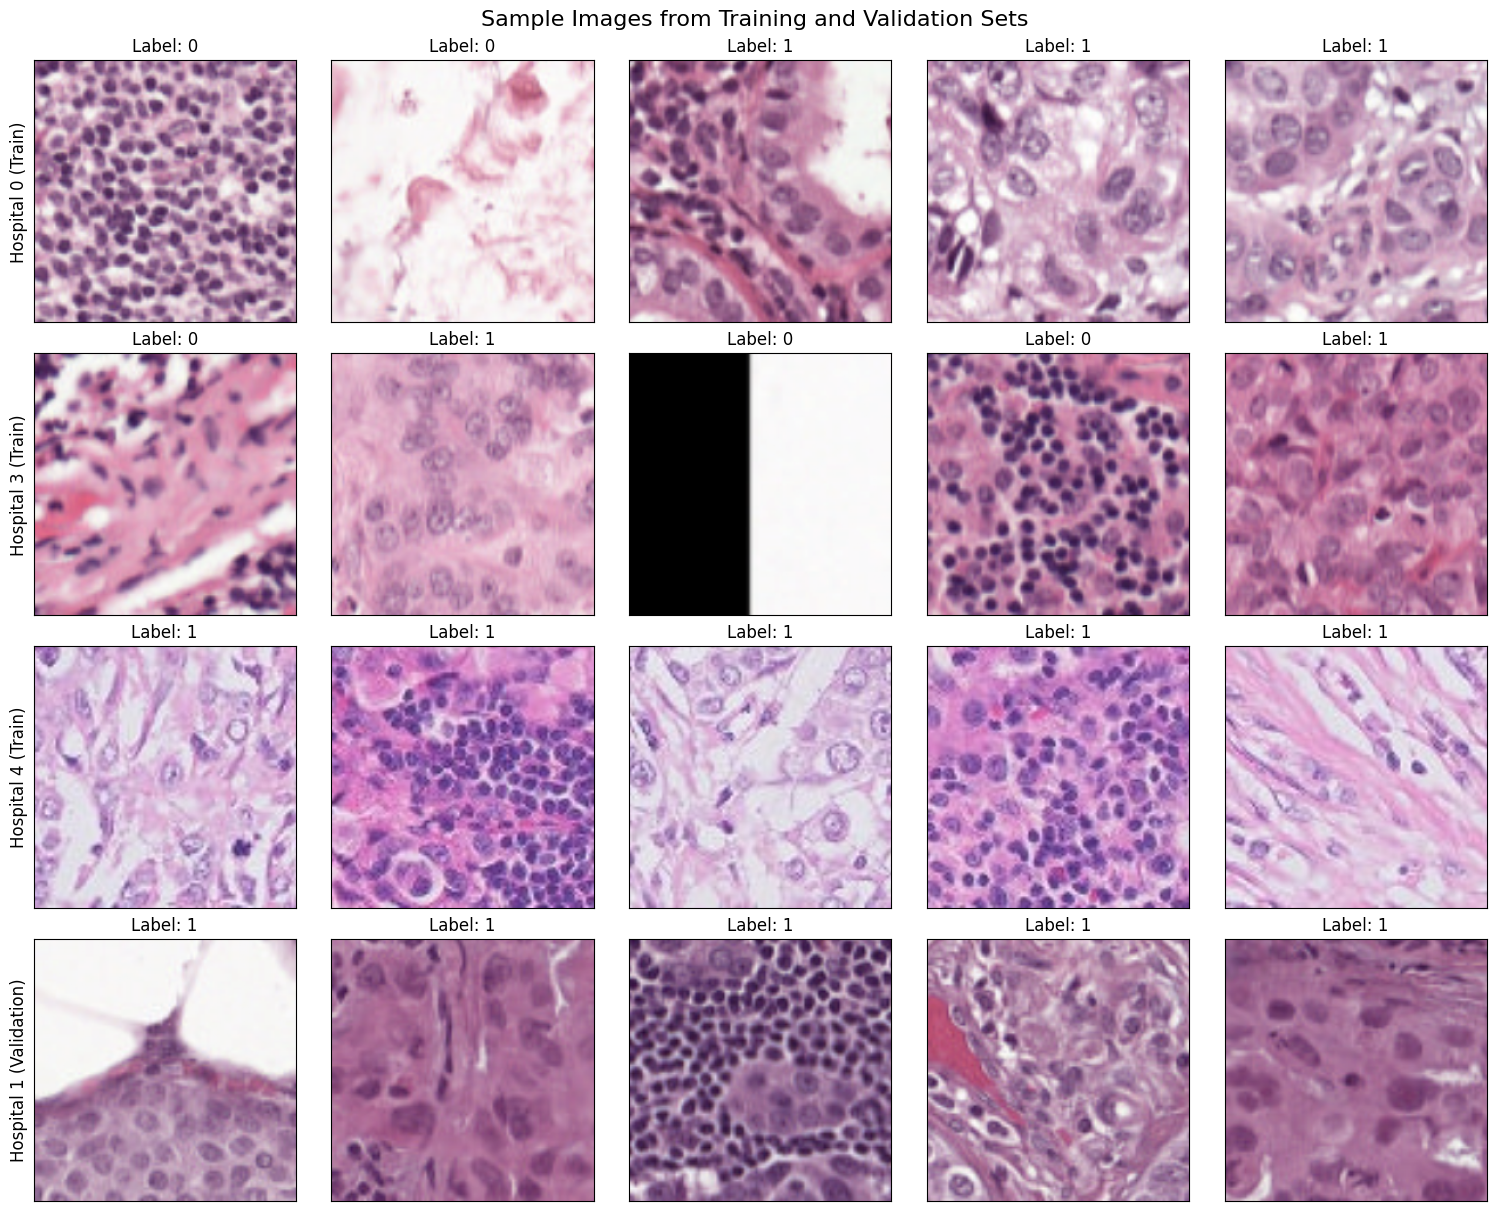

In [7]:
def denormalize(image: torch.Tensor) -> torch.Tensor:
    """Denormalizes an image tensor."""
    mean = torch.tensor([0.485, 0.456, 0.406], device=image.device).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225], device=image.device).view(3, 1, 1)
    return (image * std + mean).permute(1, 2, 0)

train_data_eda = dataset.get_subset("train", transform=transform)
val_data_eda = dataset.get_subset("val", transform=transform)
n = 5

train_hospitals = torch.unique(train_data_eda.metadata_array[:, 0])
val_hospitals = torch.unique(val_data_eda.metadata_array[:, 0])

n_hospitals = len(train_hospitals) + len(val_hospitals)

fig, axes = plt.subplots(n_hospitals, n, figsize=(n * 3, n_hospitals * 3), constrained_layout=True)
for i, hospital in enumerate(train_hospitals):
    hospital_indices = torch.where(train_data_eda.metadata_array[:, 0] == hospital)[0]
    selected_indices = np.random.choice(hospital_indices, n, replace=False)

    axes[i, 0].set_ylabel(f"Hospital {hospital.item()} (Train)", fontsize=12)

    for j, idx in enumerate(selected_indices):
        axes[i, j].set_yticks([])
        axes[i, j].set_xticks([])

        image, label, metadata= train_data_eda[idx]
        axes[i, j].imshow(denormalize(image))  # Convert from (C, H, W) to (H, W, C)
        axes[i, j].set_title(f"Label: {label.item()}")

for i, hospital in enumerate(val_hospitals, start=len(train_hospitals)):
    hospital_indices = torch.where(val_data_eda.metadata_array[:, 0] == hospital)[0]
    selected_indices = np.random.choice(hospital_indices, n, replace=False)

    axes[i, 0].set_ylabel(f"Hospital {hospital.item()} (Validation)", fontsize=12)

    for j, idx in enumerate(selected_indices):
        axes[i, j].set_yticks([])
        axes[i, j].set_xticks([])

        image, label, metadata= val_data_eda[idx]
        axes[i, j].imshow(denormalize(image))
        axes[i, j].set_title(f"Label: {label.item()}")

fig.suptitle("Sample Images from Training and Validation Sets", fontsize=16)

plt.show()


Proporção de labels por hospital (%):


label,normal (0),cancer (1)
hospital,,
0,50.00%,50.00%
1,50.00%,50.00%
2,50.00%,50.00%
3,50.00%,50.00%
4,50.00%,50.00%


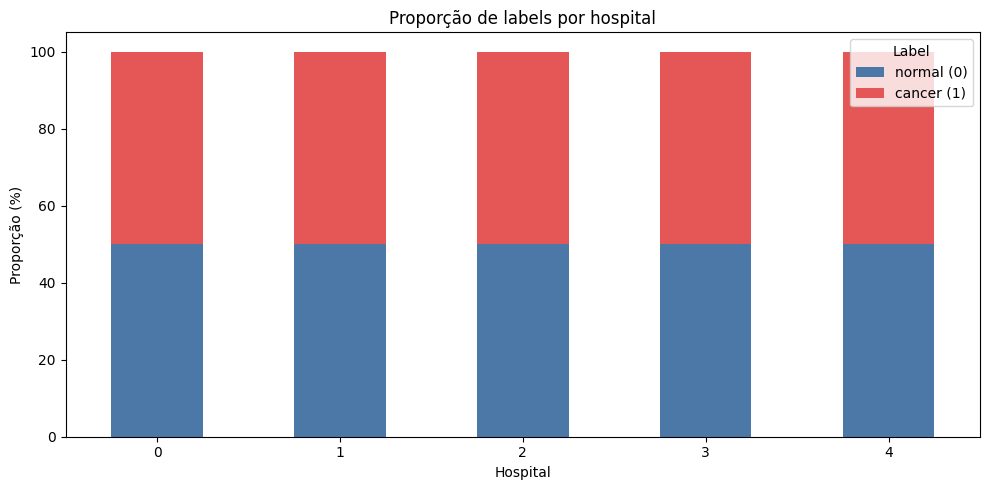

In [8]:
# Distribuição de labels (0 = normal, 1 = cancer) por hospital
import pandas as pd

hospitals = dataset.metadata_array[:, 0].cpu().numpy().astype(int)
labels = dataset.y_array.cpu().numpy().astype(int).reshape(-1)

df_dist = pd.DataFrame({"hospital": hospitals, "label": labels})

prop = (
    df_dist.groupby("hospital")["label"]
    .value_counts(normalize=True)
    .rename("proportion")
    .mul(100)
    .reset_index()
)

prop_table = (
    prop.pivot(index="hospital", columns="label", values="proportion")
    .fillna(0)
    .rename(columns={0: "normal (0)", 1: "cancer (1)"})
    .sort_index()
)

print("Proporção de labels por hospital (%):")
display(prop_table.style.format("{:.2f}%"))

ax = prop_table.plot(
    kind="bar",
    stacked=True,
    figsize=(10, 5),
    color=["#4C78A8", "#E45756"],
)
ax.set_title("Proporção de labels por hospital")
ax.set_xlabel("Hospital")
ax.set_ylabel("Proporção (%)")
ax.legend(title="Label")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

Metadata features available: ['hospital', 'slide', 'y', 'from_source_domain']


,count,mean,std,min,25%,50%,75%,max
hospital,455954.0,2.591082,1.349268,0.0,2.0,3.0,4.0,4.0
slide,455954.0,31.668749,14.348881,0.0,23.0,37.0,43.0,49.0
y,455954.0,0.500000,0.500001,0.0,0.0,0.5,1.0,1.0
from_source_domain,455954.0,0.663304,0.472581,0.0,0.0,1.0,1.0,1.0


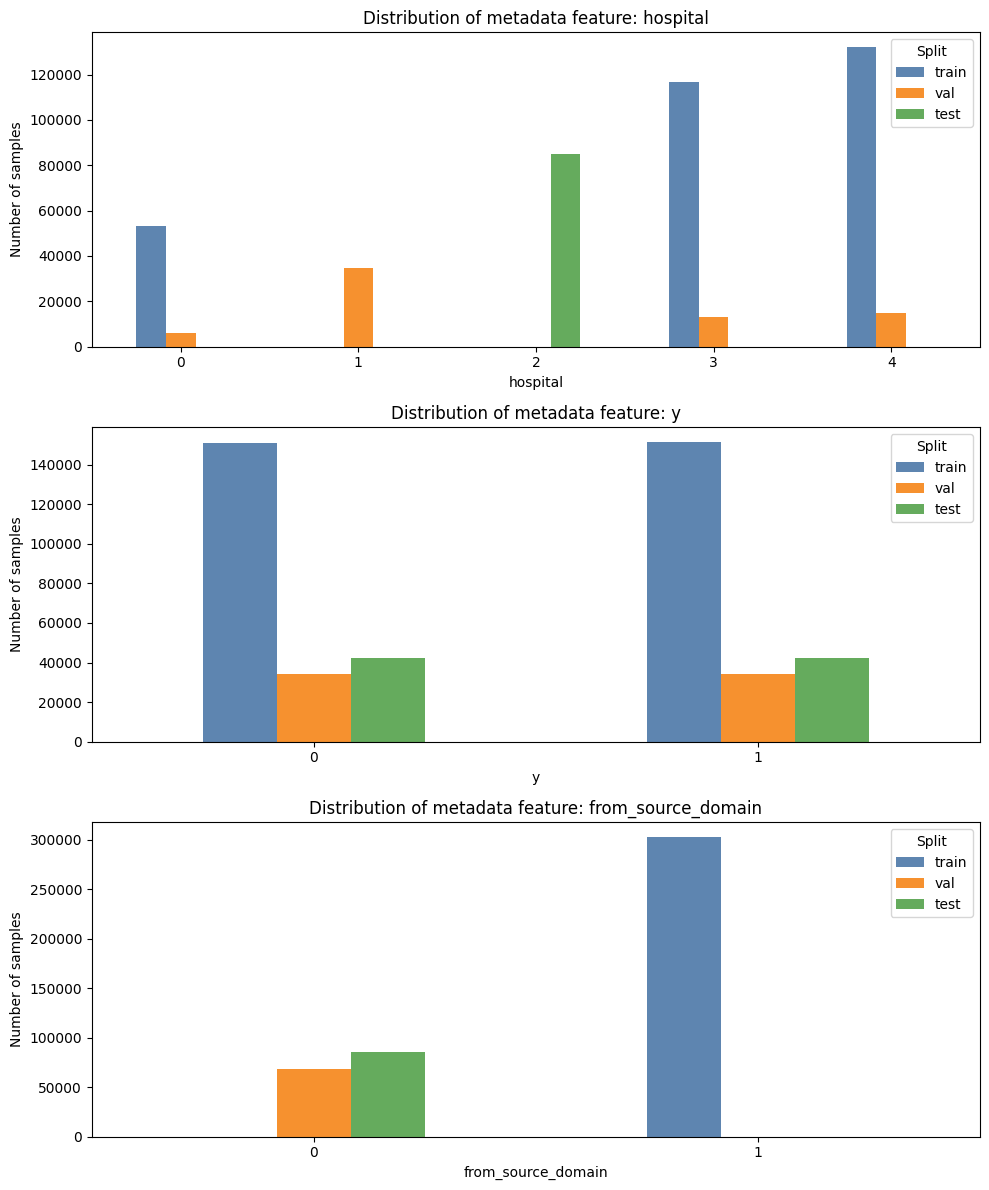

In [9]:
# Distribution of metadata features
import pandas as pd

metadata_np = dataset.metadata_array.cpu().numpy().astype(int)
field_names = list(getattr(dataset, "_metadata_fields", []))
if len(field_names) != metadata_np.shape[1]:
    field_names = [f"metadata_{i}" for i in range(metadata_np.shape[1])]

df_meta = pd.DataFrame(metadata_np, columns=field_names)

split_dict = getattr(dataset, "split_dict", {})
if split_dict:
    id_to_name = {int(split_id): split_name for split_name, split_id in split_dict.items()}
else:
    id_to_name = {0: "train", 1: "val", 2: "test"}

split_array = np.array(dataset.split_array).astype(int)
df_meta["split_raw"] = pd.Series(split_array).map(id_to_name).fillna("unknown")

# Normalize WILDS split names to the canonical train/val/test names.
split_alias = {
    "train": "train",
    "id_val": "val",
    "val": "val",
    "id_test": "test",
    "test": "test",
}
df_meta["split"] = df_meta["split_raw"].map(split_alias).fillna(df_meta["split_raw"])

df_plot = df_meta[df_meta["split"].isin(["train", "val", "test"])].copy()
if len(df_plot) == 0:
    df_plot = df_meta.copy()

print("Metadata features available:", field_names)
display(df_plot[field_names].describe(include="all").T)

plot_cols = [col for col in field_names if df_plot[col].nunique() <= 15]
if not plot_cols:
    plot_cols = field_names[: min(3, len(field_names))]

fig, axes = plt.subplots(len(plot_cols), 1, figsize=(10, 4 * len(plot_cols)), squeeze=False)
for i, col in enumerate(plot_cols):
    counts = df_plot.groupby([col, "split"]).size().unstack(fill_value=0).sort_index()
    counts = counts[[c for c in ["train", "val", "test"] if c in counts.columns]]
    counts.plot(
        kind="bar",
        ax=axes[i, 0],
        color=["#4C78A8", "#F58518", "#54A24B"],
        alpha=0.9,
    )
    axes[i, 0].set_title(f"Distribution of metadata feature: {col}")
    axes[i, 0].set_xlabel(col)
    axes[i, 0].set_ylabel("Number of samples")
    axes[i, 0].legend(title="Split")
    axes[i, 0].tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.show()

In [10]:
# Strategy 1 (cell 15): sample images and build pixel-based features by label
from torchvision import transforms

raw_transform = transforms.ToTensor()
raw_split_subsets = {
    "train": dataset.get_subset("train", transform=raw_transform),
    "val": dataset.get_subset("val", transform=raw_transform),
    "test": dataset.get_subset("test", transform=raw_transform),
}

rng = np.random.default_rng(seed)
max_images_per_label_per_split = 200
max_pixels_per_label = 300000

pixel_values_by_label = {0: [], 1: []}
rows = []

for split_name, subset in raw_split_subsets.items():
    labels_split = subset.y_array.cpu().numpy().astype(int).reshape(-1)

    for target_label in [0, 1]:
        idx_all = np.where(labels_split == target_label)[0]
        n_take = min(max_images_per_label_per_split, len(idx_all))
        idx_sampled = rng.choice(idx_all, size=n_take, replace=False)

        for idx in idx_sampled:
            image, label, metadata = subset[idx]
            image_np = image.numpy()  # shape: (3, H, W), values in [0, 1]

            r = image_np[0]
            g = image_np[1]
            b = image_np[2]
            gray = 0.299 * r + 0.587 * g + 0.114 * b

            q10, q50, q90 = np.percentile(gray, [10, 50, 90])
            rows.append(
                {
                    "split": split_name,
                    "hospital": int(metadata[0].item()) if hasattr(metadata[0], "item") else int(metadata[0]),
                    "label": int(label.item()) if hasattr(label, "item") else int(label),
                    "mean_intensity": float(gray.mean()),
                    "std_intensity": float(gray.std()),
                    "q10_intensity": float(q10),
                    "median_intensity": float(q50),
                    "q90_intensity": float(q90),
                    "contrast_q90_q10": float(q90 - q10),
                    "bright_ratio_080": float((gray > 0.80).mean()),
                    "dark_ratio_020": float((gray < 0.20).mean()),
                    "rgb_channel_gap": float(np.std([r.mean(), g.mean(), b.mean()])),
                }
            )

            flat_gray = gray.flatten()
            if flat_gray.size > 1000:
                flat_gray = rng.choice(flat_gray, size=1000, replace=False)
            pixel_values_by_label[target_label].append(flat_gray)

for target_label in [0, 1]:
    pixel_values_by_label[target_label] = np.concatenate(pixel_values_by_label[target_label])
    if pixel_values_by_label[target_label].size > max_pixels_per_label:
        pixel_values_by_label[target_label] = rng.choice(
            pixel_values_by_label[target_label], size=max_pixels_per_label, replace=False
        )

df_pixel_features = pd.DataFrame(rows)
print(f"Feature table shape: {df_pixel_features.shape}")
print("Images per label in sampled table:")
print(df_pixel_features["label"].value_counts().sort_index())
display(df_pixel_features.head())

Feature table shape: (1200, 12)
Images per label in sampled table:
label
0    600
1    600
Name: count, dtype: int64


,split,hospital,label,mean_intensity,std_intensity,q10_intensity,median_intensity,q90_intensity,contrast_q90_q10,bright_ratio_080,dark_ratio_020,rgb_channel_gap
0,train,3,0,0.430993,0.158449,0.233988,0.416767,0.645025,0.411037,0.016927,0.035048,0.078279
1,train,3,0,0.879441,0.142811,0.661798,0.959037,0.992157,0.330359,0.735135,0.000434,0.038131
2,train,3,0,0.379919,0.175607,0.169275,0.354135,0.632386,0.463112,0.010525,0.173828,0.070203
3,train,0,0,0.529614,0.155850,0.321873,0.532986,0.724267,0.402394,0.042969,0.006727,0.072911
4,train,0,0,0.524458,0.193403,0.267604,0.521049,0.780665,0.513061,0.079102,0.027127,0.058213


## Bloco EDA Centralizado

As analises que estavam separadas em notebooks auxiliares foram centralizadas aqui no notebook principal, organizadas em 4 estrategias complementares.

### Mudanca de estrategia 1: analisar shift de dominio entre hospitais

Nesta etapa, o foco e caracterizar diferencas entre hospitais (protocolos e scanners) usando estatisticas de pixels e distancias entre distribuicoes.

hospital,0,1,2,3,4
split,,,,,
test,0,0,400,0,0
train,64,0,0,161,175
val,0,400,0,0,0


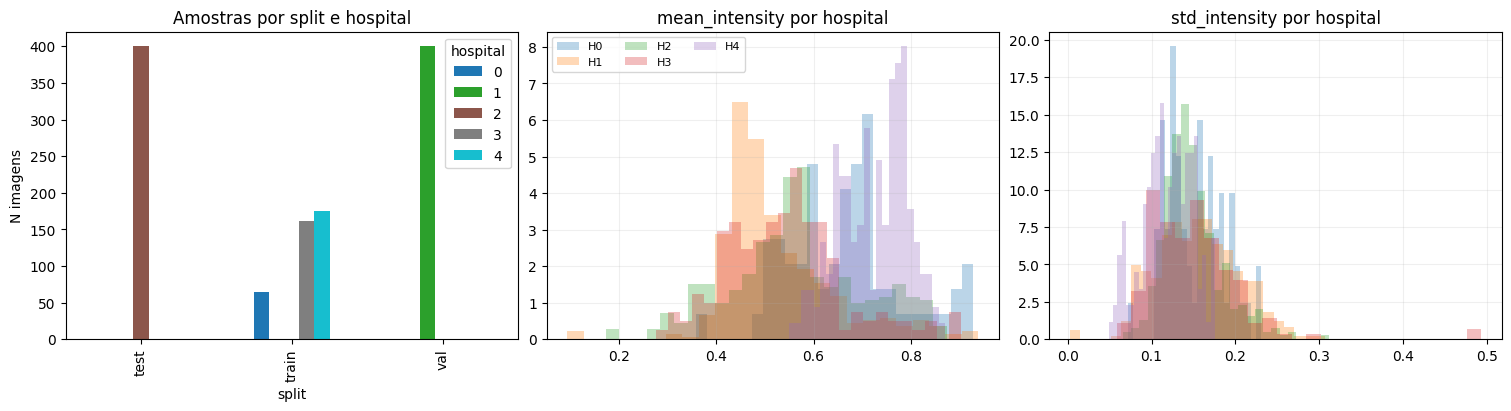

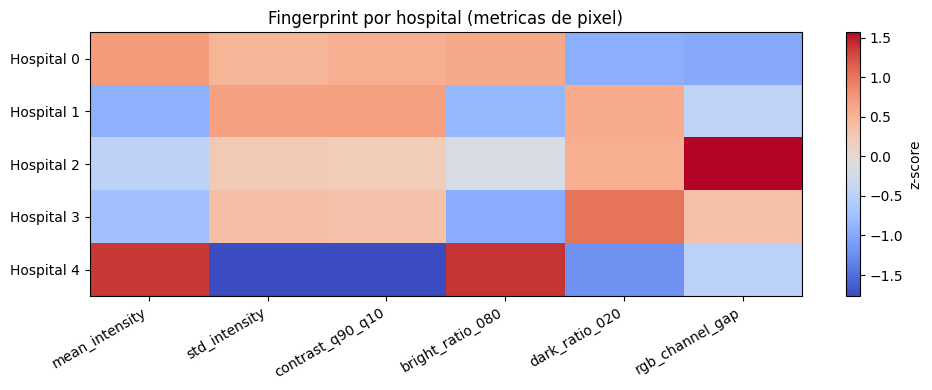

,H0,H1,H2,H3,H4
H0,0.000000,0.056926,0.047996,0.061114,0.047263
H1,0.056926,0.000000,0.029796,0.012196,0.100341
H2,0.047996,0.029796,0.000000,0.024746,0.085580
H3,0.061114,0.012196,0.024746,0.000000,0.101183
H4,0.047263,0.100341,0.085580,0.101183,0.000000


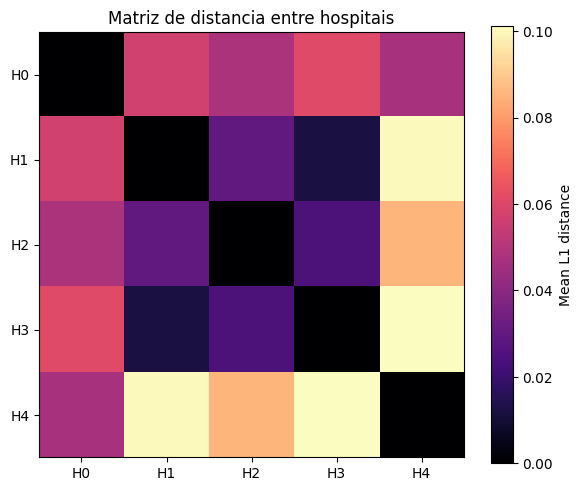

In [11]:
# Strategy 1 - Shift entre hospitais (scanner/protocolo)
if "df_pixel_features" not in globals():
    raise RuntimeError("Execute as celulas 15-18 primeiro para gerar df_pixel_features.")

metric_h = [
    "mean_intensity",
    "std_intensity",
    "contrast_q90_q10",
    "bright_ratio_080",
    "dark_ratio_020",
    "rgb_channel_gap",
]

counts_h = df_pixel_features.groupby(["split", "hospital"]).size().unstack(fill_value=0)
display(counts_h)

fig, axes = plt.subplots(1, 3, figsize=(15, 4), constrained_layout=True)
counts_h.plot(kind="bar", ax=axes[0], colormap="tab10")
axes[0].set_title("Amostras por split e hospital")
axes[0].set_ylabel("N imagens")

for metric, ax in zip(["mean_intensity", "std_intensity"], axes[1:]):
    for h in sorted(df_pixel_features["hospital"].unique()):
        vals = df_pixel_features.loc[df_pixel_features["hospital"] == h, metric].values
        ax.hist(vals, bins=25, density=True, alpha=0.3, label=f"H{h}")
    ax.set_title(f"{metric} por hospital")
    ax.grid(alpha=0.2)

axes[1].legend(ncol=3, fontsize=8)
plt.show()

agg_h = df_pixel_features.groupby("hospital")[metric_h].mean().sort_index()
z = (agg_h - agg_h.mean(axis=0)) / (agg_h.std(axis=0) + 1e-8)

plt.figure(figsize=(10, 4))
plt.imshow(z.values, cmap="coolwarm", aspect="auto")
plt.colorbar(label="z-score")
plt.xticks(range(len(metric_h)), metric_h, rotation=30, ha="right")
plt.yticks(range(len(z.index)), [f"Hospital {h}" for h in z.index])
plt.title("Fingerprint por hospital (metricas de pixel)")
plt.tight_layout()
plt.show()

dist = np.zeros((len(agg_h.index), len(agg_h.index)))
for i, hi in enumerate(agg_h.index):
    for j, hj in enumerate(agg_h.index):
        dist[i, j] = np.abs(agg_h.loc[hi].values - agg_h.loc[hj].values).mean()

dist_df = pd.DataFrame(dist, index=[f"H{h}" for h in agg_h.index], columns=[f"H{h}" for h in agg_h.index])
display(dist_df)

plt.figure(figsize=(6, 5))
plt.imshow(dist_df.values, cmap="magma")
plt.colorbar(label="Mean L1 distance")
plt.xticks(range(len(dist_df.columns)), dist_df.columns)
plt.yticks(range(len(dist_df.index)), dist_df.index)
plt.title("Matriz de distancia entre hospitais")
plt.tight_layout()
plt.show()

### Mudanca de estrategia 2: sinal global de cancer vs normal

Depois de entender o dominio, comparamos label 0 e 1 no agregado para identificar quais metricas de pixel mais diferenciam cancer de normal.

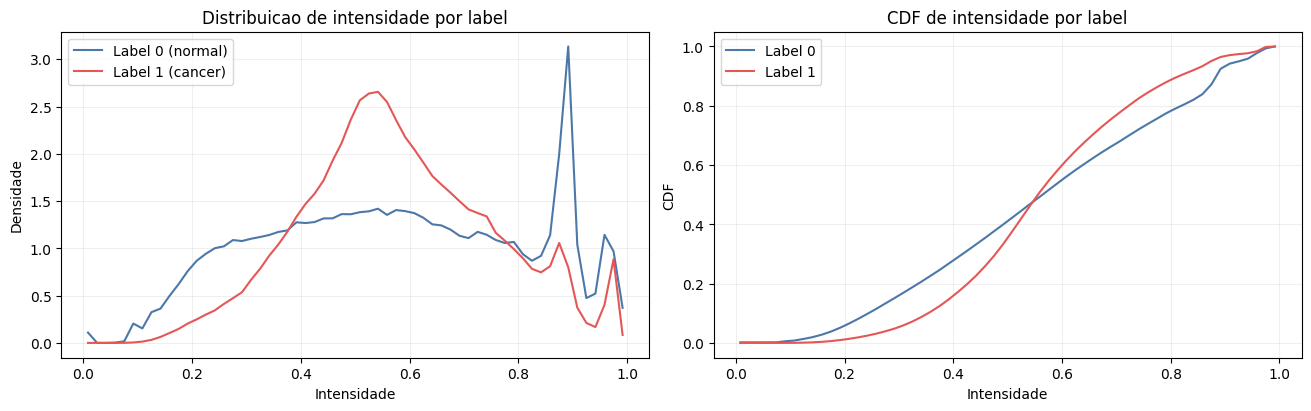

Media de intensidade L0: 0.5750
Media de intensidade L1: 0.5787
Bright ratio (>0.8) L0: 0.2253
Bright ratio (>0.8) L1: 0.1203


,metric,auc,separability_auc
1,std_intensity,0.236336,0.763664
5,contrast_q90_q10,0.256164,0.743836
7,dark_ratio_020,0.361578,0.638422
2,q10_intensity,0.635275,0.635275
6,bright_ratio_080,0.366719,0.633281
8,rgb_channel_gap,0.633253,0.633253
4,q90_intensity,0.384071,0.615929
3,median_intensity,0.526625,0.526625
0,mean_intensity,0.515214,0.515214


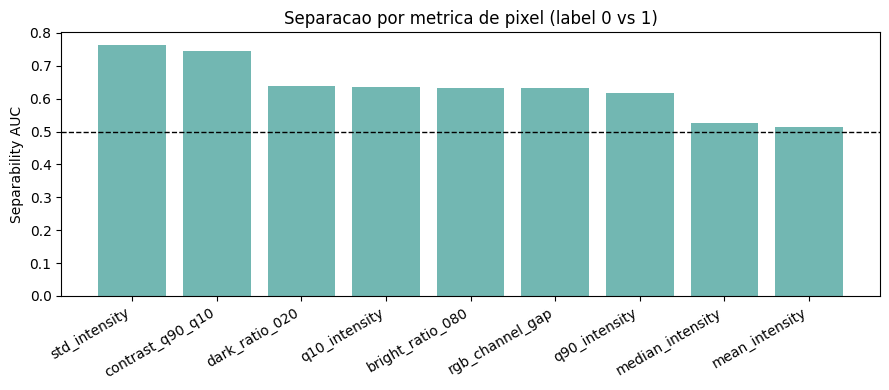

In [12]:
# Strategy 2 - Sinal global de label (cancer vs normal)
bins = np.linspace(0.0, 1.0, 61)
centers = (bins[:-1] + bins[1:]) / 2

pix0 = pixel_values_by_label[0]
pix1 = pixel_values_by_label[1]
h0, _ = np.histogram(pix0, bins=bins, density=True)
h1, _ = np.histogram(pix1, bins=bins, density=True)

fig, axes = plt.subplots(1, 2, figsize=(13, 4), constrained_layout=True)
axes[0].plot(centers, h0, label="Label 0 (normal)", color="#4C78A8")
axes[0].plot(centers, h1, label="Label 1 (cancer)", color="#E45756")
axes[0].set_title("Distribuicao de intensidade por label")
axes[0].set_xlabel("Intensidade")
axes[0].set_ylabel("Densidade")
axes[0].legend()
axes[0].grid(alpha=0.2)

axes[1].plot(centers, np.cumsum(h0) / np.sum(h0), label="Label 0", color="#4C78A8")
axes[1].plot(centers, np.cumsum(h1) / np.sum(h1), label="Label 1", color="#E45756")
axes[1].set_title("CDF de intensidade por label")
axes[1].set_xlabel("Intensidade")
axes[1].set_ylabel("CDF")
axes[1].legend()
axes[1].grid(alpha=0.2)
plt.show()

print(f"Media de intensidade L0: {pix0.mean():.4f}")
print(f"Media de intensidade L1: {pix1.mean():.4f}")
print(f"Bright ratio (>0.8) L0: {(pix0 > 0.8).mean():.4f}")
print(f"Bright ratio (>0.8) L1: {(pix1 > 0.8).mean():.4f}")

metric_cols = [
    "mean_intensity",
    "std_intensity",
    "q10_intensity",
    "median_intensity",
    "q90_intensity",
    "contrast_q90_q10",
    "bright_ratio_080",
    "dark_ratio_020",
    "rgb_channel_gap",
]

y_true = df_pixel_features["label"].values
rank_rows = []
for m in metric_cols:
    vals = df_pixel_features[m].values
    auc = roc_auc_score(y_true, vals)
    rank_rows.append(
        {
            "metric": m,
            "auc": float(auc),
            "separability_auc": float(max(auc, 1 - auc)),
        }
    )

rank_df = pd.DataFrame(rank_rows).sort_values("separability_auc", ascending=False)
display(rank_df)

plt.figure(figsize=(9, 4))
plt.bar(rank_df["metric"], rank_df["separability_auc"], color="#72B7B2")
plt.axhline(0.5, color="black", linestyle="--", linewidth=1)
plt.xticks(rotation=30, ha="right")
plt.ylabel("Separability AUC")
plt.title("Separacao por metrica de pixel (label 0 vs 1)")
plt.tight_layout()
plt.show()

### Mudanca de estrategia 3: interacao hospital x label

Aqui verificamos se as diferencas entre cancer e normal sao consistentes entre hospitais ou se mudam de acordo com o dominio (hospital/scanner).

metric,bright_ratio_080,contrast_q90_q10,dark_ratio_020,mean_intensity,std_intensity
hospital,,,,,
0,-0.186839,-0.077739,-0.007116,-0.018158,-0.030620
1,-0.060728,-0.149960,-0.045938,0.004330,-0.051757
2,-0.204708,-0.033008,-0.050809,-0.023457,-0.018632
3,-0.087908,-0.169915,-0.066675,0.048304,-0.063485
4,0.049388,-0.060151,-0.000025,0.038801,-0.019386


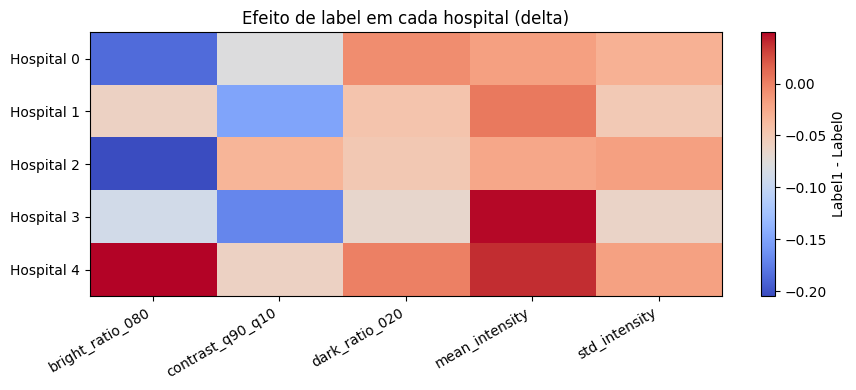

,metric,sign_consistency
1,contrast_q90_q10,1.0
4,std_intensity,1.0
2,dark_ratio_020,1.0
0,bright_ratio_080,0.8
3,mean_intensity,0.4


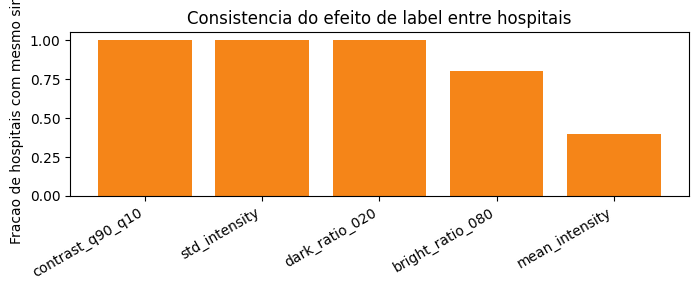

In [13]:
# Strategy 3 - Interacao hospital x label (consistencia do sinal)
metrics_inter = ["mean_intensity", "std_intensity", "contrast_q90_q10", "bright_ratio_080", "dark_ratio_020"]

delta_rows = []
for h in sorted(df_pixel_features["hospital"].unique()):
    d = df_pixel_features[df_pixel_features["hospital"] == h]
    if d["label"].nunique() < 2:
        continue
    for m in metrics_inter:
        m0 = d.loc[d["label"] == 0, m].mean()
        m1 = d.loc[d["label"] == 1, m].mean()
        delta_rows.append({"hospital": h, "metric": m, "delta_label1_minus_0": float(m1 - m0)})

delta_df = pd.DataFrame(delta_rows)
delta_pivot = delta_df.pivot(index="hospital", columns="metric", values="delta_label1_minus_0").sort_index()
display(delta_pivot)

plt.figure(figsize=(9, 4))
plt.imshow(delta_pivot.values, cmap="coolwarm", aspect="auto")
plt.colorbar(label="Label1 - Label0")
plt.xticks(range(len(delta_pivot.columns)), delta_pivot.columns, rotation=30, ha="right")
plt.yticks(range(len(delta_pivot.index)), [f"Hospital {h}" for h in delta_pivot.index])
plt.title("Efeito de label em cada hospital (delta)")
plt.tight_layout()
plt.show()

sign_df = np.sign(delta_pivot)
consistency_rows = []
for m in delta_pivot.columns:
    vals = sign_df[m].dropna().values
    consistency = float(np.mean(vals == vals[0])) if len(vals) else np.nan
    consistency_rows.append({"metric": m, "sign_consistency": consistency})

consistency_df = pd.DataFrame(consistency_rows).sort_values("sign_consistency", ascending=False)
display(consistency_df)

plt.figure(figsize=(7, 3))
plt.bar(consistency_df["metric"], consistency_df["sign_consistency"], color="#F58518")
plt.ylim(0, 1.05)
plt.ylabel("Fracao de hospitais com mesmo sinal")
plt.xticks(rotation=30, ha="right")
plt.title("Consistencia do efeito de label entre hospitais")
plt.tight_layout()
plt.show()

### Mudanca de estrategia 4: baseline preditivo com features de pixels

Depois de analisar metricas isoladas, agora combinamos todas as features em um modelo simples (regressao logistica) para medir o poder preditivo conjunto e a generalizacao em val/test.

,split,auc,accuracy
0,train,0.820000,0.7300
1,val,0.844075,0.7900
2,test,0.819025,0.7075


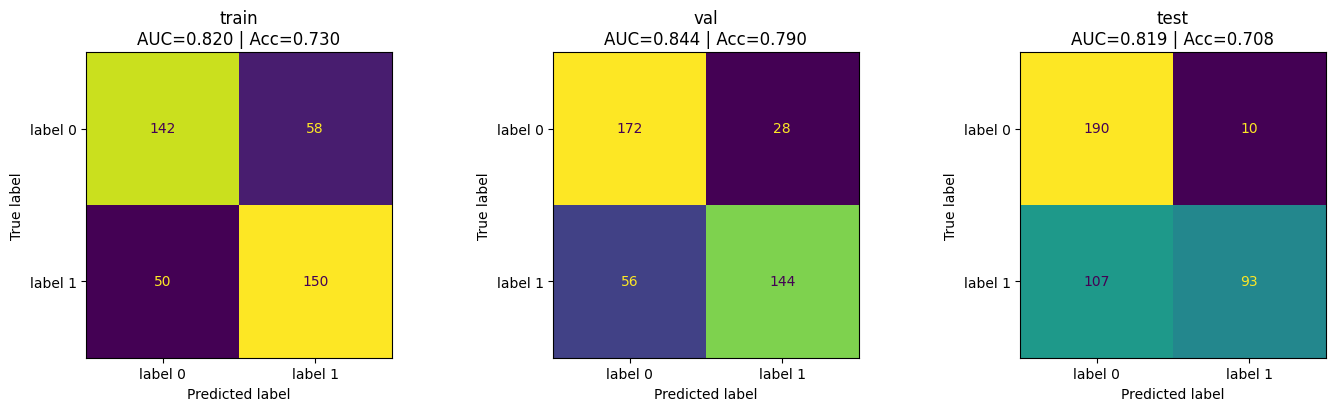

<Figure size 600x500 with 0 Axes>

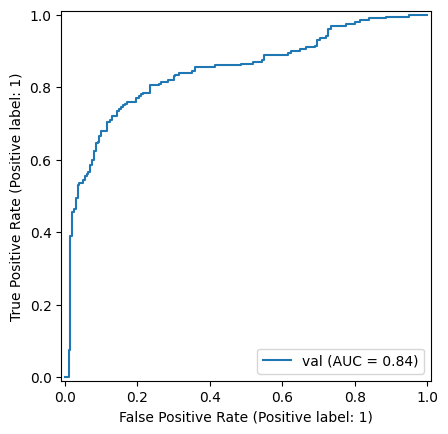

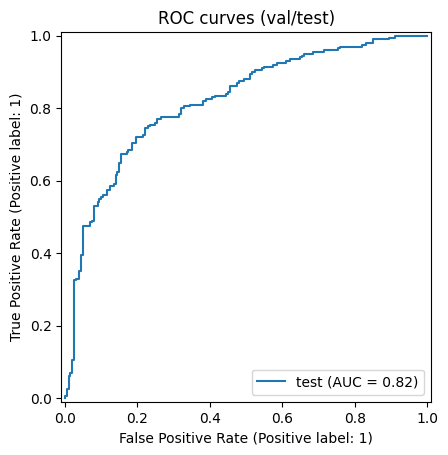

,feature,coef
6,bright_ratio_080,-1.394738
5,contrast_q90_q10,-0.740924
0,mean_intensity,0.709640
1,std_intensity,-0.426379
4,q90_intensity,-0.401345
8,rgb_channel_gap,-0.311437
7,dark_ratio_020,-0.305866
2,q10_intensity,0.299703
3,median_intensity,0.094986


In [14]:
# Strategy 4 - Baseline preditivo com features de pixels (sinal combinado)
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay, RocCurveDisplay

feature_cols = [
    "mean_intensity",
    "std_intensity",
    "q10_intensity",
    "median_intensity",
    "q90_intensity",
    "contrast_q90_q10",
    "bright_ratio_080",
    "dark_ratio_020",
    "rgb_channel_gap",
]

df_train = df_pixel_features[df_pixel_features["split"] == "train"].copy()
df_val = df_pixel_features[df_pixel_features["split"] == "val"].copy()
df_test = df_pixel_features[df_pixel_features["split"] == "test"].copy()

X_train = df_train[feature_cols].values
y_train = df_train["label"].values
X_val = df_val[feature_cols].values
y_val = df_val["label"].values
X_test = df_test[feature_cols].values
y_test = df_test["label"].values

clf = make_pipeline(StandardScaler(), LogisticRegression(max_iter=2500, random_state=seed))
clf.fit(X_train, y_train)

def eval_split(name, X, y):
    probs = clf.predict_proba(X)[:, 1]
    preds = (probs >= 0.5).astype(int)
    return {
        "split": name,
        "auc": float(roc_auc_score(y, probs)),
        "accuracy": float(accuracy_score(y, preds)),
        "cm": confusion_matrix(y, preds),
        "y": y,
        "probs": probs,
    }

res = [
    eval_split("train", X_train, y_train),
    eval_split("val", X_val, y_val),
    eval_split("test", X_test, y_test),
]

display(pd.DataFrame([{"split": r["split"], "auc": r["auc"], "accuracy": r["accuracy"]} for r in res]))

fig, axes = plt.subplots(1, 3, figsize=(14, 4), constrained_layout=True)
for ax, r in zip(axes, res):
    ConfusionMatrixDisplay(r["cm"], display_labels=["label 0", "label 1"]).plot(ax=ax, colorbar=False)
    ax.set_title(f"{r['split']}\nAUC={r['auc']:.3f} | Acc={r['accuracy']:.3f}")
plt.show()

plt.figure(figsize=(6, 5))
for r in res[1:]:
    RocCurveDisplay.from_predictions(r["y"], r["probs"], name=r["split"])
plt.title("ROC curves (val/test)")
plt.show()

coef = clf.named_steps["logisticregression"].coef_[0]
coef_df = pd.DataFrame({"feature": feature_cols, "coef": coef, "abs_coef": np.abs(coef)}).sort_values("abs_coef", ascending=False)
display(coef_df[["feature", "coef"]])

Resumo das Features:

1. Intensidade (pixel intensity)
    E o valor de brilho do pixel, normalmente em escala 0-1:

    - 0 = muito escuro

    - 1 = muito claro
    Quando usamos grayscale, cada pixel vira um unico valor de brilho.

2. mean_intensity

    Media dos valores de intensidade da imagem inteira.

    Interpreta como “brilho medio global”.

3. std_intensity
    Desvio padrao das intensidades.
    Mede variacao de tons: alto std = imagem mais heterogenea/“texturizada”.

4. q10_intensity, median_intensity, q90_intensity

    Quantis da distribuicao de intensidade:

    - q10: limite dos 10% mais escuros

    - median: valor central

    - q90: limite dos 10% mais claros
    Isso descreve o perfil de luminosidade sem depender so da media.

5. contrast_q90_q10

    Definido como q90 - q10.
    Mede contraste interno: quanto maior, maior separacao entre regioes escuras e claras.

6. bright_ratio_080
    Proporcao de pixels com intensidade > 0.8.
    Mede quanto da imagem esta “muito clara”.

7. dark_ratio_020
    Proporcao de pixels com intensidade < 0.2.
    Mede quanto da imagem esta “muito escura”.

8. rgb_channel_gap
    Desvio entre medias dos canais R, G e B.
    Mede desequilibrio de cor (estilo de coloracao/scanner).

Como mensurar textura de forma simples:

std_intensity: variacao global de tons.

contrast_q90_q10: contraste interno.

> **Question.** (1.0 pts)
> 
> What are your findings? Describe the task, the characteristics you have found, possible challenges that you will encounter, and other initial hypothesis.
> 
> Do you think a neural network will be able to classify tumors and generalize to other hospitals?

A tarefa e classificacao binaria de patches histopatologicos em normal (0) e cancer (1) sob shift de dominio entre hospitais (train: 0/3/4, val: 1, test: 2). A exploracao mostrou que existe diferenca real de distribuicao entre hospitais: medias, variancias, contraste e composicao de intensidades mudam entre centros, o que sugere efeito de protocolo de coloracao e scanner. A matriz de distancia entre hospitais reforca que alguns centros sao mais proximos entre si e outros mais distintos.

No sinal de classe (label), observamos que media de intensidade sozinha separa pouco (AUC proximo de 0.5), mas metricas de textura/variacao e caudas de intensidade separam melhor, por exemplo `std_intensity` e `contrast_q90_q10` (AUC univariado mais alto). Alem disso, ao analisar hospital x label, algumas metricas (como contraste e desvio padrao) mantem direcao semelhante entre hospitais, enquanto outras (como media de intensidade) variam mais de centro para centro.

O baseline com regressao logistica em features de pixel combinadas apresentou bom poder de separacao (AUC ~0.82-0.84), com queda de acuracia no test OOD. Isso indica que existe sinal util para detectar tumor, mas parte dele nao transfere perfeitamente para hospital nao visto.

Possiveis desafios:

1.Domain shift entre hospitais (estilo de imagem, brilho, contraste, cor).
2. Risco de aprendizado de correlacoes espurias ligadas ao scanner/protocolo em vez de morfologia tumoral.
3. Gap entre desempenho ID e OOD, especialmente no balanceamento entre falsos positivos e falsos negativos.

Hipoteses iniciais:

1. Um modelo convolucional deve aprender sinal morfologico relevante e superar baseline de pixel bruto.
2. Sem controle de shift (augmentacao, normalizacao adequada, regularizacao), parte do ganho em treino/val pode nao generalizar para test.
3. Estrategias que reduzam dependencia de estilo (ex.: augmentacao de cor, normalizacao por stain, ou abordagens robustas a dominio) tendem a reduzir o gap ID-OOD.

Resposta sobre NN:

Sim, uma rede neural deve conseguir classificar tumores com boa performance. Porem, generalizar para outros hospitais e o principal desafio; portanto esperamos bom desempenho ID, mas com possivel queda em OOD se o modelo capturar sinais de dominio em vez de sinais biologicos robustos.

---

## Experiment 1: Transfer Model (Baseline)

[ResNet-18](https://arxiv.org/abs/1512.03385) is a convolutional neural network pretrained on ImageNet, a large-scale dataset of natural images spanning 1,000 object categories.
It is one of the most widely used backbones in transfer-learning pipelines due to its representation capacity across a broad domain of images.
Although it is often treated as a generic feature extractor, its architecture embeds several structural assumptions about images, which become encoded in the learned weights.
When transferring the model to histopathology, it is not immediately clear which of these assumptions remain useful, which are irrelevant, and which may even be harmful.

> **Question:**
>
>What inductive biases does a pretrained ResNet-18 inherit from pretraining on ImageNet, and do they transfer to histopathology?

> **Hypothesis:** 
>
> A pretrained ResNet-18 encodes local visual structures via hierarchical convolutional filters that generalize beyond natural images.
> As a result, a **linear classifier** trained on top of *frozen* ResNet features (a linear probe) should achieve accuracy substantially above 50% on both ID validation and OOD test data, despite the large domain gap between natural and histopathology images.

> **Baseline:**
>
> Random chance is 50% accuracy for balanced binary classification.

In [15]:
# Representation cached from the ResNet-18 backbone
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from torchvision.models import resnet18, ResNet18_Weights
from tqdm.auto import tqdm

train_loader = DataLoader(train_data, batch_size=128, shuffle=True, num_workers=4)
val_loader = DataLoader(val_data, batch_size=128, shuffle=False, num_workers=4)

train_features_cache = FEATURE_CACHE_DIR / f"resnet_train_features_{RUN_TAG}.pt"
val_features_cache = FEATURE_CACHE_DIR / f"resnet_val_features_{RUN_TAG}.pt"

backbone = resnet18(weights=ResNet18_Weights.IMAGENET1K_V1)
backbone.fc = nn.Identity()  # Remove the final classification layer to get features instead of predictions.
backbone.eval().to(DEVICE)

if train_features_cache.exists() and val_features_cache.exists():
    train_pack = torch.load(train_features_cache, map_location="cpu")
    val_pack = torch.load(val_features_cache, map_location="cpu")
    train_features = train_pack["features"]
    train_labels = train_pack["labels"]
    val_features = val_pack["features"]
    val_labels = val_pack["labels"]
else:
    with torch.no_grad():
        train_features = []
        train_labels = []
        for images, labels, _ in tqdm(train_loader, desc="Extracting train features"):
            images = images.to(DEVICE)
            features = backbone(images).cpu()
            train_features.append(features)
            train_labels.append(labels)

        val_features = []
        val_labels = []
        for images, labels, _ in tqdm(val_loader, desc="Extracting validation features"):
            images = images.to(DEVICE)
            features = backbone(images).cpu()
            val_features.append(features)
            val_labels.append(labels)

    train_features = torch.cat(train_features)
    train_labels = torch.cat(train_labels)
    val_features = torch.cat(val_features)
    val_labels = torch.cat(val_labels)

    torch.save({"features": train_features, "labels": train_labels}, train_features_cache)
    torch.save({"features": val_features, "labels": val_labels}, val_features_cache)


resnet_train_dataset = TensorDataset(train_features, train_labels)
resnet_val_dataset = TensorDataset(val_features, val_labels)

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 194MB/s]
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


Extracting train features:   0%|          | 0/2363 [00:00<?, ?it/s]

Extracting validation features:   0%|          | 0/273 [00:00<?, ?it/s]

In [16]:
# You can modify the following methods as you want.
import numpy as np
import torch
import torch.nn as nn
from pathlib import Path
from torch import optim
from torch.utils.data import DataLoader
from tqdm.auto import tqdm
from sklearn.metrics import roc_auc_score, accuracy_score, confusion_matrix, ConfusionMatrixDisplay

CACHE_DIR = Path("cache")
CHECKPOINT_DIR = CACHE_DIR / "checkpoints"
FEATURE_CACHE_DIR = CACHE_DIR / "features"
RESULTS_CACHE_DIR = CACHE_DIR / "results"
for directory in [CACHE_DIR, CHECKPOINT_DIR, FEATURE_CACHE_DIR, RESULTS_CACHE_DIR]:
    directory.mkdir(parents=True, exist_ok=True)


def save_checkpoint(path: Path, model: nn.Module, optimizer: optim.Optimizer | None = None, history: dict | None = None) -> None:
    payload = {"model_state_dict": model.state_dict()}
    if optimizer is not None:
        payload["optimizer_state_dict"] = optimizer.state_dict()
    if history is not None:
        payload["history"] = history
    torch.save(payload, path)


def load_checkpoint(path: Path, model: nn.Module, optimizer: optim.Optimizer | None = None) -> dict | None:
    if not path.exists():
        return None
    payload = torch.load(path, map_location=DEVICE)
    model.load_state_dict(payload["model_state_dict"])
    if optimizer is not None and "optimizer_state_dict" in payload:
        optimizer.load_state_dict(payload["optimizer_state_dict"])
    return payload.get("history")


def train_model(
    model: nn.Module,
    train_loader: DataLoader,
    criterion: nn.Module,
    optimizer: optim.Optimizer,
    n_epochs: int,
) -> dict[str, list[float]]:
    """Trains the model and returns the training history."""
    history = {
        "epoch_loss": [],
    }

    model.to(DEVICE)
    for epoch in range(n_epochs):
        model.train()
        epoch_loss = 0.0

        pbar = tqdm(train_loader, desc=f"Epoch {epoch + 1}/{n_epochs}", leave=False)
        for batch_data in pbar:
            # Supports both (x, y) and (x, y, metadata) batches.
            if len(batch_data) == 3:
                images, labels, _ = batch_data
            else:
                images, labels = batch_data

            images = images.to(DEVICE)
            labels = labels.float().unsqueeze(1).to(DEVICE)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            epoch_loss += loss.item() * images.size(0)
            pbar.set_postfix(batch_loss=f"{loss.item():.4f}")

        epoch_loss /= len(train_loader.dataset)
        history["epoch_loss"].append(epoch_loss)
        print(f"Epoch {epoch + 1}/{n_epochs} | Loss: {epoch_loss:.4f}")

    return history


def evaluate_model(
    model: nn.Module,
    data_loader: DataLoader,
    threshold: float = 0.5,
) -> dict[str, float | np.ndarray]:
    """Evaluates the model and returns AUC-ROC, accuracy and confusion matrix."""
    model.eval()
    all_labels = []
    all_probs = []

    with torch.no_grad():
        for batch_data in data_loader:
            if len(batch_data) == 3:
                images, labels, _ = batch_data
            else:
                images, labels = batch_data

            images = images.to(DEVICE)
            logits = model(images)
            probs = torch.sigmoid(logits).cpu().numpy().flatten()

            all_probs.extend(probs)
            all_labels.extend(labels.cpu().numpy().flatten())

    all_labels = np.array(all_labels)
    all_probs = np.array(all_probs)
    all_preds = (all_probs >= threshold).astype(int)

    auc_roc = float(roc_auc_score(all_labels, all_probs))
    acc = float(accuracy_score(all_labels, all_preds))
    cm = confusion_matrix(all_labels, all_preds)

    return {
        "auc_roc": auc_roc,
        "accuracy": acc,
        "confusion_matrix": cm,
        "labels": all_labels,
        "probs": all_probs,
    }

In [17]:
class LinearProbe(nn.Module):
    """Linear probe on top of the ResNet-18 backbone."""
    def __init__(self, input_dim: int, num_classes: int) -> None:
        super().__init__()
        self.fc = nn.Linear(input_dim, num_classes)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.fc(x)

In [18]:
train_loader = DataLoader(resnet_train_dataset, batch_size=128, shuffle=True, num_workers=4)
val_loader = DataLoader(resnet_val_dataset, batch_size=128, shuffle=False, num_workers=4)

input_dim = resnet_train_dataset.tensors[0].shape[1]
model = LinearProbe(input_dim=input_dim, num_classes=1).to(DEVICE)

optimizer = optim.Adam(model.parameters(), lr=1e-5)
criterion = nn.BCEWithLogitsLoss()

linear_probe_ckpt = CHECKPOINT_DIR / f"linear_probe_{RUN_TAG}.pt"
linear_probe_history_file = RESULTS_CACHE_DIR / f"linear_probe_history_{RUN_TAG}.pt"

cached_history = load_checkpoint(linear_probe_ckpt, model, optimizer)
if cached_history is not None and linear_probe_history_file.exists():
    history = torch.load(linear_probe_history_file, map_location="cpu")
    print(f"Loaded cached linear probe checkpoint from {linear_probe_ckpt}")
else:
    history = train_model(model, train_loader, criterion, optimizer, n_epochs=2 if DEBUG_SMALL_RUN else 20)
    save_checkpoint(linear_probe_ckpt, model, optimizer, history)
    torch.save(history, linear_probe_history_file)

Epoch 1/20:   0%|          | 0/2363 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x784c42b67f60>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x784c42b67f60>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
Exception ignored in:     self._shutdown_workers()<function _MultiProcessingDataLoaderIter.__del__ at 0x784c42b67f60>

Epoch 1/20 | Loss: 0.5154


Epoch 2/20:   0%|          | 0/2363 [00:00<?, ?it/s]

Epoch 2/20 | Loss: 0.3530


...

Epoch 19/20:   0%|          | 0/2363 [00:00<?, ?it/s]

Exception ignored in: Exception ignored in: Exception ignored in: Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x784c42b67f60><function _MultiProcessingDataLoaderIter.__del__ at 0x784c42b67f60><function _MultiProcessingDataLoaderIter.__del__ at 0x784c42b67f60><function _MultiProcessingDataLoaderIter.__del__ at 0x784c42b67f60>


Traceback (most recent call last):

Traceback (most recent call last):
Traceback (most recent call last):
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
              File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    self._shutdown_workers()self._shutdown_workers()self._shutdown_workers()

Epoch 19/20 | Loss: 0.1831


Epoch 20/20:   0%|          | 0/2363 [00:00<?, ?it/s]

Epoch 20/20 | Loss: 0.1818


Exception ignored in: Exception ignored in: Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x784c42b67f60><function _MultiProcessingDataLoaderIter.__del__ at 0x784c42b67f60><function _MultiProcessingDataLoaderIter.__del__ at 0x784c42b67f60>
Traceback (most recent call last):


Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
          File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    self._shutdown_workers()self._shutdown_workers()
self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers

  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
  F

Linear Probe Results
Train AUC-ROC: 0.9789 | Train Accuracy: 0.9338
Val   AUC-ROC: 0.9393 | Val   Accuracy: 0.8582


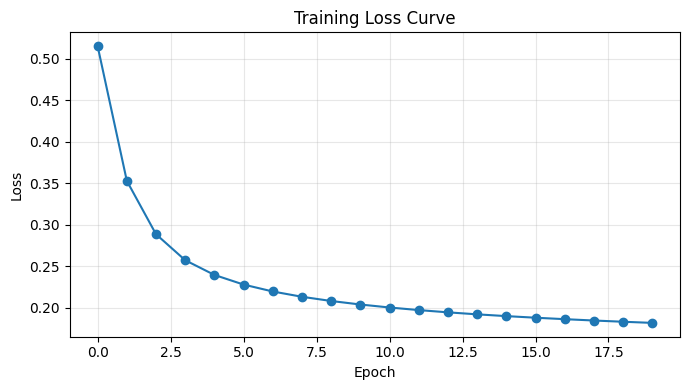

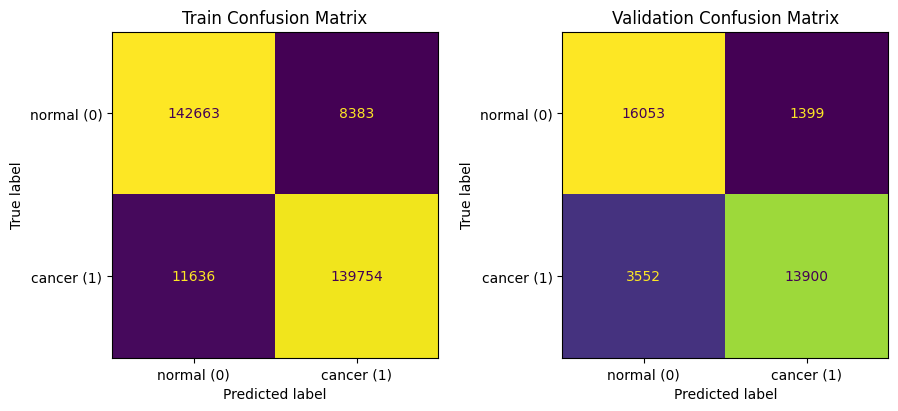

In [19]:
# Evaluate the model on the validation set and visualize training history.
train_metrics_cache = RESULTS_CACHE_DIR / f"linear_probe_train_metrics_{RUN_TAG}.pt"
val_metrics_cache = RESULTS_CACHE_DIR / f"linear_probe_val_metrics_{RUN_TAG}.pt"

if train_metrics_cache.exists() and val_metrics_cache.exists():
    train_metrics = torch.load(train_metrics_cache, map_location="cpu", weights_only=False)
    val_metrics = torch.load(val_metrics_cache, map_location="cpu", weights_only=False)
    print("Loaded cached linear probe metrics")
else:
    train_metrics = evaluate_model(model, train_loader)
    val_metrics = evaluate_model(model, val_loader)
    torch.save(train_metrics, train_metrics_cache)
    torch.save(val_metrics, val_metrics_cache)

print("Linear Probe Results")
print(f"Train AUC-ROC: {train_metrics['auc_roc']:.4f} | Train Accuracy: {train_metrics['accuracy']:.4f}")
print(f"Val   AUC-ROC: {val_metrics['auc_roc']:.4f} | Val   Accuracy: {val_metrics['accuracy']:.4f}")

plt.figure(figsize=(7, 4))
plt.plot(history["epoch_loss"], marker="o")
plt.title("Training Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(9, 4), constrained_layout=True)
ConfusionMatrixDisplay(train_metrics["confusion_matrix"], display_labels=["normal (0)", "cancer (1)"]).plot(
    ax=axes[0], colorbar=False
)
axes[0].set_title("Train Confusion Matrix")

ConfusionMatrixDisplay(val_metrics["confusion_matrix"], display_labels=["normal (0)", "cancer (1)"]).plot(
    ax=axes[1], colorbar=False
)
axes[1].set_title("Validation Confusion Matrix")

plt.show()

### Design justification

> **Question.** (1.0 pts)
> 
> Why changing only the last layer of the pretrained ResNet-18 is a reasonable baseline for this dataset?
>
> Explain what were the metrics that you used to test the hypothesis and why they help answering the question.

*YOUR ANSWER HERE*

Realizar o Linear Probing, treinando apenas a última camada, é um bom baseline porque aproveita do conhecimento já aprendido pela ResNet-18. Em CNNs as camadas iniciais e intermediárias atuam como extratores de características de baixo nível. Embora imagens de tecidos não sejam tão presentes em datasets como o do ImageNet, essas características geométricas e de textura são altamente transferíveis e úteis para histopatologia. Além disso, como uma baseline, essa abordagem é computacionalmente eficiente e atua como um limite inferior de performance. Ela consegue previnir o overfitting resultante das especifidades de cada hospital, com seus protocolos, cores características... permitindo verificar se a rede consegue separar as classes linearmente no espaço latente antes de partirmos para o fine-tuning completo da rede.

As nossas métricas foram AUC-ROC e Accuracy. A Accuracy mede a proporção total de labels corretas, enquanto a AUC-ROC mede a capacidade do modelo de distinguir entre as classes, independentemente do limiar de decisão, ou seja, uma AUC de 0.93 significa que se pegarmos aleatoriamente uma imagem com câncer e uma imagem normal, há 93% de chance de o modelo dar uma probabilidade maior de ser câncer para a imagem que realmente tem a doença do que para a saudável.

A partir dessas metricas, definimos que a baseline de Linear Probing obteve uma boa AUC (0.93), mas a análise do erro mostra que a sensibilidade ainda precisa melhorar, o que justifica a necessidade de realizar o fine-tuning de mais camadas da rede, ou aplicar técnicas de atenção e regularização, para que o modelo aprenda características mais complexas e específicas que reduzam essa taxa de falsos negativos perante a variabilidade dos dados dos diferentes hospitais.

### Discussion

> **Question.** (1.0 pts) 
> 
> Discuss the results of using a frozen backbone. Address the following points:
> 
> Do the results support or contradict the hypothesis? Refer to specific numbers.
>
> What does the gap between metrics ID vs OOD imply about the representations?
>
> What limitations does the linear probe evaluation have when assessing the quality of the pretrained representations?
> Can we correctly attribute what is causing the observed performance?

A abordagem de linear probe com o backbone congelado apoia parcialmente a hipótese: o desempenho está claramente acima do acaso, alcançando uma AUC-ROC de Treino de 0.9789 e uma Acurácia de Treino de 0.9338. Isso indica que as características pré-treinadas na ImageNet retêm estruturas visuais úteis para a histopatologia. No entanto, a queda perceptível para uma AUC-ROC de Validação de 0.9393 e uma Acurácia de Validação de 0.8582 indica que a representação ainda é limitada sob mudança de domínio.

Principais descobertas:

O linear probe alcançou um forte desempenho na distribuição de treinamento, mas o desempenho de validação/OOD é inferior ao de treino, uma queda de ~7,5% na acurácia, indicando uma clara lacuna de generalização. Essa lacuna sugere que parte da representação congelada captura pistas específicas de estilo ou de cada hospital (pigmentação, scanner, contraste) além da própria morfologia do tecido.

Como apenas um cabeçalho linear é treinado, o modelo não consegue adaptar a extração de características aos padrões específicos da histopatologia.

Implicações para a qualidade da representação:

Filtros convolucionais pré-treinados transferem estruturas úteis de baixo e médio nível, mas a transferência é incompleta: as características extraídas com a rede congelada não são totalmente invariantes à mudança de diferentes hospitais.

Limitações da avaliação via linear probe:

Ela testa apenas a separabilidade linear de características fixas, e não o melhor desempenho que poderia ser alcançado na tarefa. Não consegue separar se os ganhos de desempenho vêm da verdadeira morfologia do tumor ou de correlações do domínio dos hospitais.

Portanto, não podemos atribuir o desempenho observado a uma única causa com certeza; precisamos realizar estudos de ablação controlados para isolar os mecanismos envolvidos.

---

## Experiment 2: Is the CNN Structure Necessary?

ResNet is a convolutional architecture, meaning it builds in several strong assumptions: 
- local feature detection via small kernels
- spatial weight sharing
- hierarchical composition of features

These are not universal truths about image data, they are inductive biases that may or may not be useful for a given task.

A model with no spatial inductive bias, such as a multilayer perceptron (MLP) applied to flattened pixels, treats every pixel independently and must learn spatial relationships from data alone.
Comparing the two isolates the contribution of the convolutional inductive bias from all other factors.

This comparison also illustrates a central theme of this assignment: **raw parameter count does not determine generalization**.
As you will see, the MLP on 96×96×3 input has a first hidden layer alone with more parameters than the entire CNN, yet it may perform worse, demonstrating that inductive alignment with the data structure matters more than model capacity.

Note that, as we changed a lot of things when compared with the previous experiment, we cannot make a direct comparison, but we can see the performance on a baseline that already solves the problem.

> **Question:** Does the spatial inductive bias of a convolutional architecture improve generalization over a non-spatial model with comparable or greater parameter count?

### Hypothesis

> **Hypothesis.** (1.0 pts)
>
> *State a falsifiable hypothesis. Your hypothesis should make a concrete, directional prediction about the ID accuracy, OOD accuracy, and/or ID–OOD gap for the MLP vs SmallCNN. Refer to specific structural properties you expect to matter.*



We hypothesize that **SmallCNN** will outperform **MLP** on both ID and OOD evaluation, even if the MLP has comparable or larger parameter count.

Directional prediction:

1. CNN will achieve higher validation AUC/accuracy than MLP.
2. CNN will achieve higher OOD test AUC/accuracy than MLP.
3. CNN will show a smaller ID-OOD gap, because spatial inductive bias (local filters and weight sharing) is better aligned with histopathology morphology than fully connected pixel-wise modeling.

In [20]:
class MLP(nn.Module):
    """Fully connected network."""

    def __init__(self, input_size: int, hidden_dims: list[int], dropout: float = 0.3) -> None:
        super().__init__()

        dims = [input_size] + hidden_dims + [1]
        layers: list[nn.Module] = []

        for i in range(len(dims) - 2):
            layers.extend(
                [
                    nn.Linear(dims[i], dims[i + 1]),
                    nn.ReLU(),
                    nn.Dropout(dropout),
                ]
            )

        layers.append(nn.Linear(dims[-2], dims[-1]))
        self.net = nn.Sequential(*layers)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = x.view(x.size(0), -1)
        return self.net(x)


class SmallCNN(nn.Module):
    """Small convolutional network, spatial inductive bias."""

    def __init__(self, dropout: float = 0.3, num_classes: int = 1) -> None:
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )

        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Dropout(dropout),
            nn.Linear(128, num_classes),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.features(x)
        return self.classifier(x)

In [21]:
# For this experiment, you can change the data transforms if you want.
# We recommend using smaller input sizes (e.g., the raw data is 96×96)
# for the MLP and SmallCNN, since they have fewer parameters than the ResNet-18
# and will overfit more easily on the full 224×224 images.
# You can use the same normalization as before, or recompute the mean and std
# on the smaller input size.

SIZE = 96

transform = transforms.Compose(
    [
        # You can uncomment the line below if you want to use a different input size.
        # transforms.Resize((SIZE, SIZE)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]), 
    ]
)

train_data = make_debug_subset(dataset.get_subset("train", transform=transform), DEBUG_TRAIN_SAMPLES, seed)
val_data = make_debug_subset(dataset.get_subset("val", transform=transform), DEBUG_VAL_SAMPLES, seed)
test_data = make_debug_subset(dataset.get_subset("test", transform=transform), DEBUG_TEST_SAMPLES, seed)

In [22]:
mlp_input_dim = SIZE * SIZE * 3  # 96 × 96 × 3 = 27,648

mlp = MLP(input_size=mlp_input_dim, hidden_dims=[512, 256])
cnn = SmallCNN()


def count_params(model: nn.Module) -> int:
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


print(f"MLP total parameters : {count_params(mlp):>12,}")
print(f"CNN total parameters : {count_params(cnn):>12,}")
print()
print("Note: both models receive the same 96×96×3 input and the same training procedure.")

MLP total parameters :   14,287,873
CNN total parameters :       93,825

Note: both models receive the same 96×96×3 input and the same training procedure.


In [23]:
image_train_loader = DataLoader(train_data, batch_size=128, shuffle=True, num_workers=4)
image_val_loader = DataLoader(val_data, batch_size=128, shuffle=False, num_workers=4)
image_test_loader = DataLoader(test_data, batch_size=128, shuffle=False, num_workers=4)

# Keep a local alias for this experiment only.
train_loader = image_train_loader
val_loader = image_val_loader
test_loader = image_test_loader

# Fair-comparison setup for both models.
learning_rate = 1e-3
n_epochs = 1 if DEBUG_SMALL_RUN else 5
dropout = 0.3

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


In [24]:
mlp = MLP(input_size=mlp_input_dim, hidden_dims=[512, 256], dropout=dropout).to(DEVICE)

mlp_optimizer = optim.AdamW(mlp.parameters(), lr=learning_rate)
mlp_criterion = nn.BCEWithLogitsLoss()

mlp_ckpt = CHECKPOINT_DIR / f"mlp_{RUN_TAG}.pt"
mlp_history_file = RESULTS_CACHE_DIR / f"mlp_history_{RUN_TAG}.pt"
cached_mlp_history = load_checkpoint(mlp_ckpt, mlp, mlp_optimizer)
if cached_mlp_history is not None and mlp_history_file.exists():
    train_mlp_history = torch.load(mlp_history_file, map_location="cpu")
    print(f"Loaded cached MLP checkpoint from {mlp_ckpt}")
else:
    train_mlp_history = train_model(
        mlp,
        image_train_loader,
        mlp_criterion,
        mlp_optimizer,
        n_epochs=n_epochs,
    )
    save_checkpoint(mlp_ckpt, mlp, mlp_optimizer, train_mlp_history)
    torch.save(train_mlp_history, mlp_history_file)

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


Epoch 1/5:   0%|          | 0/2363 [00:00<?, ?it/s]

Epoch 1/5 | Loss: 0.5611


Epoch 2/5:   0%|          | 0/2363 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x784c42b67f60>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x784c42b67f60>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 16

...

Exception ignored in: Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x784c42b67f60><function _MultiProcessingDataLoaderIter.__del__ at 0x784c42b67f60>

Traceback (most recent call last):
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
        self._shutdown_workers()self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers

  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
        if w.is_alive():
if w.is_alive(): 
             ^^^^^^^^^^^^^^^^^^^^
^  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
Exception ignored in: ^    ^<function _MultiProcessingDataLoaderIter.__del__ at 0x784c42b67f60>assert s

Epoch 4/5 | Loss: 0.4315


Epoch 5/5:   0%|          | 0/2363 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x784c42b67f60>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x784c42b67f60>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 16

Epoch 5/5 | Loss: 0.4168


In [25]:
cnn = SmallCNN(dropout=dropout).to(DEVICE)

cnn_optimizer = optim.AdamW(cnn.parameters(), lr=learning_rate)
cnn_criterion = nn.BCEWithLogitsLoss()

cnn_ckpt = CHECKPOINT_DIR / f"cnn_{RUN_TAG}.pt"
cnn_history_file = RESULTS_CACHE_DIR / f"cnn_history_{RUN_TAG}.pt"
cached_cnn_history = load_checkpoint(cnn_ckpt, cnn, cnn_optimizer)
if cached_cnn_history is not None and cnn_history_file.exists():
    train_cnn_history = torch.load(cnn_history_file, map_location="cpu")
    print(f"Loaded cached CNN checkpoint from {cnn_ckpt}")
else:
    train_cnn_history = train_model(
        cnn,
        image_train_loader,
        cnn_criterion,
        cnn_optimizer,
        n_epochs=n_epochs,
    )
    save_checkpoint(cnn_ckpt, cnn, cnn_optimizer, train_cnn_history)
    torch.save(train_cnn_history, cnn_history_file)

Epoch 1/5:   0%|          | 0/2363 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x784c42b67f60>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
    if w.is_alive():
    Exception ignored in:  <function _MultiProcessingDataLoaderIter.__del__ at 0x784c42b67f60>  
Traceback (most recent call last):
^  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
^    ^^self._shutdown_workers()^
^  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
^    ^if w.is_alive():^Exception ignored in: ^
<function _MultiProcessingDataLoaderIter.__del__ at 0x784c42b67f60> ^
 ^Traceback (most recent call last):
   File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/datalo

Epoch 1/5 | Loss: 0.1449


Epoch 2/5:   0%|          | 0/2363 [00:00<?, ?it/s]

Epoch 2/5 | Loss: 0.1008


...

Exception ignored in: Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x784c42b67f60>
<function _MultiProcessingDataLoaderIter.__del__ at 0x784c42b67f60>Traceback (most recent call last):

Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
        self._shutdown_workers()self._shutdown_workers()

  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
        if w.is_alive():if w.is_alive():

Exception ignored in:  <function _MultiProcessingDataLoaderIter.__del__ at 0x784c42b67f60>  
    File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
Traceback (most rece

Epoch 4/5 | Loss: 0.0781


Epoch 5/5:   0%|          | 0/2363 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x784c42b67f60>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x784c42b67f60>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 16

Epoch 5/5 | Loss: 0.0723


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
/usr/local/lib/python3.12/dist-packages/to

,model,split,auc_roc,accuracy
0,MLP,val (ID),0.756410,0.614858
1,MLP,test (OOD),0.480375,0.424530
2,SmallCNN,val (ID),0.853695,0.750917
3,SmallCNN,test (OOD),0.746131,0.688257


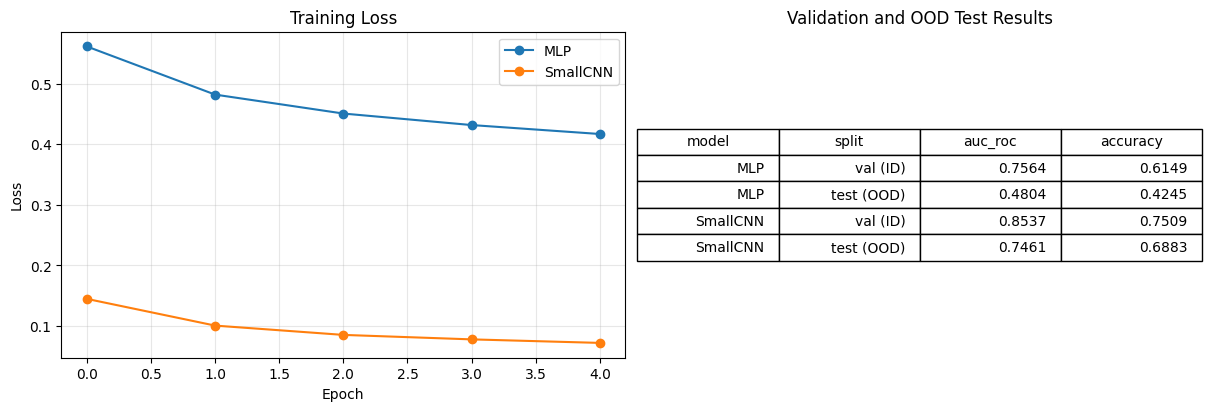

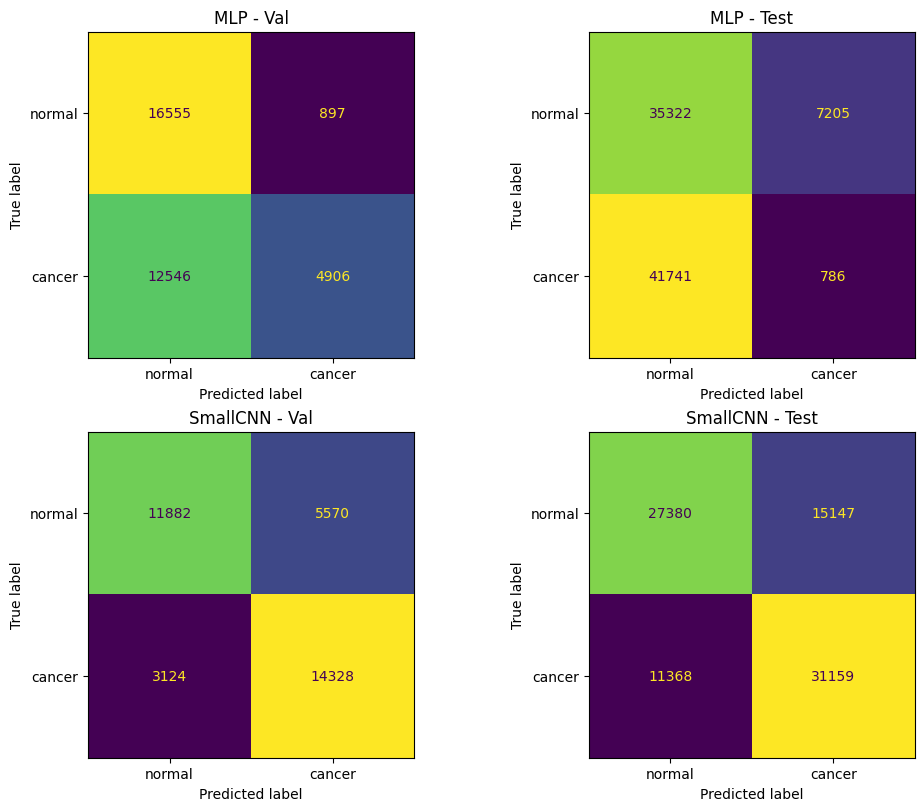

ID-OOD AUC gap
MLP      : 0.2760
SmallCNN : 0.1076


In [26]:
import pandas as pd
from sklearn.metrics import ConfusionMatrixDisplay

# Compare training curves and evaluate both models on validation and OOD test.
# Reuse saved artifacts if the training cells were not executed in the current session.
if "train_mlp_history" not in globals() and mlp_history_file.exists():
    train_mlp_history = torch.load(mlp_history_file, map_location="cpu")

if "train_cnn_history" not in globals() and cnn_history_file.exists():
    train_cnn_history = torch.load(cnn_history_file, map_location="cpu")

if "mlp" not in globals():
    mlp = MLP(input_size=mlp_input_dim, hidden_dims=[512, 256], dropout=dropout).to(DEVICE)
    load_checkpoint(mlp_ckpt, mlp)

if "cnn" not in globals():
    cnn = SmallCNN(dropout=dropout).to(DEVICE)
    load_checkpoint(cnn_ckpt, cnn)

fig, axes = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)
axes[0].plot(train_mlp_history["epoch_loss"], marker="o", label="MLP")
axes[0].plot(train_cnn_history["epoch_loss"], marker="o", label="SmallCNN")
axes[0].set_title("Training Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].grid(alpha=0.3)
axes[0].legend()

mlp_val_metrics = evaluate_model(mlp, image_val_loader)
mlp_test_metrics = evaluate_model(mlp, image_test_loader)
cnn_val_metrics = evaluate_model(cnn, image_val_loader)
cnn_test_metrics = evaluate_model(cnn, image_test_loader)

results_df = pd.DataFrame(
    [
        {
            "model": "MLP",
            "split": "val (ID)",
            "auc_roc": mlp_val_metrics["auc_roc"],
            "accuracy": mlp_val_metrics["accuracy"],
        },
        {
            "model": "MLP",
            "split": "test (OOD)",
            "auc_roc": mlp_test_metrics["auc_roc"],
            "accuracy": mlp_test_metrics["accuracy"],
        },
        {
            "model": "SmallCNN",
            "split": "val (ID)",
            "auc_roc": cnn_val_metrics["auc_roc"],
            "accuracy": cnn_val_metrics["accuracy"],
        },
        {
            "model": "SmallCNN",
            "split": "test (OOD)",
            "auc_roc": cnn_test_metrics["auc_roc"],
            "accuracy": cnn_test_metrics["accuracy"],
        },
    ]
)

display(results_df)

table_df = results_df.copy()
table_df["auc_roc"] = table_df["auc_roc"].map(lambda value: f"{value:.4f}")
table_df["accuracy"] = table_df["accuracy"].map(lambda value: f"{value:.4f}")

axes[1].axis("off")
table = axes[1].table(
    cellText=table_df.values,
    colLabels=table_df.columns,
    loc="center",
)
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 1.5)
axes[1].set_title("Validation and OOD Test Results")
plt.show()

fig, cm_axes = plt.subplots(2, 2, figsize=(10, 8), constrained_layout=True)
ConfusionMatrixDisplay(mlp_val_metrics["confusion_matrix"], display_labels=["normal", "cancer"]).plot(ax=cm_axes[0, 0], colorbar=False)
cm_axes[0, 0].set_title("MLP - Val")

ConfusionMatrixDisplay(mlp_test_metrics["confusion_matrix"], display_labels=["normal", "cancer"]).plot(ax=cm_axes[0, 1], colorbar=False)
cm_axes[0, 1].set_title("MLP - Test")

ConfusionMatrixDisplay(cnn_val_metrics["confusion_matrix"], display_labels=["normal", "cancer"]).plot(ax=cm_axes[1, 0], colorbar=False)
cm_axes[1, 0].set_title("SmallCNN - Val")

ConfusionMatrixDisplay(cnn_test_metrics["confusion_matrix"], display_labels=["normal", "cancer"]).plot(ax=cm_axes[1, 1], colorbar=False)
cm_axes[1, 1].set_title("SmallCNN - Test")
plt.show()

print("ID-OOD AUC gap")
print(f"MLP      : {mlp_val_metrics['auc_roc'] - mlp_test_metrics['auc_roc']:.4f}")
print(f"SmallCNN : {cnn_val_metrics['auc_roc'] - cnn_test_metrics['auc_roc']:.4f}")

### Design justification

> **Question.** (1.0 pts)
>
> Why comparing MLP vs SmallCNN (both trained from scratch on the same data) isolates the contribution of the convolutional inductive bias?
> 
> What aspect of the your implementation makes it an atomic ablation?

*YOUR ANSWER HERE*

### Discussion

> **Question.** (1.0 pts) 
> 
> Discuss the results of using MLP vs CNN in generalization. Address the following points:
> 
> Do the results support or contradict your hypothesis? Refer to specific metric values.
>
> Compare the ID–OOD gap for MLP vs CNN. Which model generalizes better to the unseen center, and why might that be?
>
> The MLP has more parameters than the CNN, did this fact influenced the generalization aspect of the MLP?
>
> How do the from-scratch models compare to the frozen ResNet from Experiment 1?

*YOUR ANSWER HERE*

---

## Experiment 3: Are Colors a Required Feature?

A potential issue in the data is that, different hospitals use different techniques for collecting data.
One example of such change is how the stain intensity shift across hospital centers.

Because each center has a different scanner and staining protocol, the color distribution of a patch partially encodes which hospital it came from.
This creates a potential **spurious correlation**: a model trained on centers 0–2 may learn to use color as a predictive cue, even though color is determined by the imaging center rather than by tumor status.

Under center shift (training on centers 0–2, testing on center 4), a model that relies on color will encounter a new color distribution and may fail even if the morphological signal is present.

> **Question:** Does the previous CNN rely on color information to predict tumor status, and does removing color change the generalizaion gap?

### Hypothesis

> **Hypothesis.** (1.0 pts)
>
> *State a falsifiable hypothesis. Your hypothesis should predict the direction of the change in ID accuracy, OOD accuracy, and/or ID–OOD gap when switching from RGB to grayscale input. Relate your prediction to the color distribution visualization from the Data Exploration section.*

*YOUR ANSWER HERE*

A CNN do Experimento 2 depende da coloração específica dos hospitais de treino como uma correlação espúria para prever o status do tumor.
Ao converter as imagens para escala de cinza (removendo a informação de cor), a acurácia/AUC In-Distribution (ID) deverá sofrer uma leve queda, pois o "atalho" visual foi removido. Em contrapartida, o modelo será forçado a focar nas características morfológicas das células (que são invariantes entre os centros), resultando em um aumento na métrica Out-of-Distribution (OOD) e, consequentemente, na redução significativa do ID–OOD gap.
Essa hipótese poderá ser refutada se, por outro lado, a conversão para a escala cinza aumentar o gap de generalização ou degradar a performance OOD.

In [27]:
# Maintain the same configurations you set on the previous cells (e.g. input size, normalization, etc.) to
# isolate the effect of changing the data assumptions.

transform = transforms.Compose(
    [
        # Uncomment the line below if you want to use a different input size.
        # transforms.Resize((SIZE, SIZE)),
        transforms.Grayscale(num_output_channels=3),  # Convert to 3-channel grayscale to use the same architecture as before.
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]),
    ]
)

train_data = make_debug_subset(dataset.get_subset("train", transform=transform), DEBUG_TRAIN_SAMPLES, seed)
val_data = make_debug_subset(dataset.get_subset("val", transform=transform), DEBUG_VAL_SAMPLES, seed)
test_data = make_debug_subset(dataset.get_subset("test", transform=transform), DEBUG_TEST_SAMPLES, seed)

In [28]:
# Your code here
# Train, evaluate and analyze.

SIZE = 96
learning_rate = 1e-3
n_epochs = 1 if 'DEBUG_SMALL_RUN' in globals() and DEBUG_SMALL_RUN else 5
dropout = 0.3
batch_size = 128

transform_gray = transforms.Compose(
    [
        transforms.Grayscale(num_output_channels=3),  # Mantém 3 canais para usar a mesma SmallCNN
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]),
    ]
)

# Criação dos datasets em escala de cinza
gray_train_data = make_debug_subset(dataset.get_subset("train", transform=transform_gray), DEBUG_TRAIN_SAMPLES, seed)
gray_val_data = make_debug_subset(dataset.get_subset("val", transform=transform_gray), DEBUG_VAL_SAMPLES, seed)
gray_test_data = make_debug_subset(dataset.get_subset("test", transform=transform_gray), DEBUG_TEST_SAMPLES, seed)

# DataLoaders
gray_train_loader = DataLoader(gray_train_data, batch_size=batch_size, shuffle=True, num_workers=4)
gray_val_loader = DataLoader(gray_val_data, batch_size=batch_size, shuffle=False, num_workers=4)
gray_test_loader = DataLoader(gray_test_data, batch_size=batch_size, shuffle=False, num_workers=4)

# Inicializando uma nova SmallCNN para treinar do zero nas imagens cinzas
cnn_gray = SmallCNN(dropout=dropout).to(DEVICE)
cnn_gray_optimizer = optim.AdamW(cnn_gray.parameters(), lr=learning_rate)
cnn_gray_criterion = nn.BCEWithLogitsLoss()

# Lógica de Checkpoint
cnn_gray_ckpt = CHECKPOINT_DIR / f"cnn_gray_{RUN_TAG}.pt"
cnn_gray_history_file = RESULTS_CACHE_DIR / f"cnn_gray_history_{RUN_TAG}.pt"

cached_cnn_gray_history = load_checkpoint(cnn_gray_ckpt, cnn_gray, cnn_gray_optimizer)

if cached_cnn_gray_history is not None and cnn_gray_history_file.exists():
    train_cnn_gray_history = torch.load(cnn_gray_history_file, map_location="cpu")
    print(f"Loaded cached Grayscale CNN checkpoint from {cnn_gray_ckpt}")
else:
    print("Iniciando treinamento da SmallCNN (Grayscale)...")
    train_cnn_gray_history = train_model(
        cnn_gray,
        gray_train_loader,
        cnn_gray_criterion,
        cnn_gray_optimizer,
        n_epochs=n_epochs,
    )
    save_checkpoint(cnn_gray_ckpt, cnn_gray, cnn_gray_optimizer, train_cnn_gray_history)
    torch.save(train_cnn_gray_history, cnn_gray_history_file)

# Avaliação
cnn_gray_val_metrics = evaluate_model(cnn_gray, gray_val_loader)
cnn_gray_test_metrics = evaluate_model(cnn_gray, gray_test_loader)


#  Visualizando/Comparando com o exp2
# Tabela Comparativa
results_gray_df = pd.DataFrame(
    [
        {"model": "SmallCNN (RGB)", "split": "val (ID)", "auc_roc": cnn_val_metrics["auc_roc"], "accuracy": cnn_val_metrics["accuracy"]},
        {"model": "SmallCNN (RGB)", "split": "test (OOD)", "auc_roc": cnn_test_metrics["auc_roc"], "accuracy": cnn_test_metrics["accuracy"]},
        {"model": "SmallCNN (Grayscale)", "split": "val (ID)", "auc_roc": cnn_gray_val_metrics["auc_roc"], "accuracy": cnn_gray_val_metrics["accuracy"]},
        {"model": "SmallCNN (Grayscale)", "split": "test (OOD)", "auc_roc": cnn_gray_test_metrics["auc_roc"], "accuracy": cnn_gray_test_metrics["accuracy"]},
    ]
)
display(results_gray_df)

Iniciando treinamento da SmallCNN (Grayscale)...


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


Epoch 1/5:   0%|          | 0/2363 [00:00<?, ?it/s]

Epoch 1/5 | Loss: 0.2335


Epoch 2/5:   0%|          | 0/2363 [00:00<?, ?it/s]

...

Epoch 5/5:   0%|          | 0/2363 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x784c42b67f60>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
Exception ignored in:     <function _MultiProcessingDataLoaderIter.__del__ at 0x784c42b67f60>self._shutdown_workers()
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__

  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
    self._shutdown_workers()
      File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
if w.is_alive():    
 if w.is_alive(): 
Exception ignored in:   <function _MultiProcessingDataLoaderIter.__del__ at 0x784c42b67f60>    
Traceback (most recent call last):
    File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", li

Epoch 5/5 | Loss: 0.1239


Exception ignored in: Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x784c42b67f60>
<function _MultiProcessingDataLoaderIter.__del__ at 0x784c42b67f60>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    Traceback (most recent call last):
self._shutdown_workers()  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__

      File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
self._shutdown_workers()
      File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
if w.is_alive():
     if w.is_alive(): 
        ^   ^ ^^^^^^^^^^^^^^^^^^^^^^
Exception ignored in: 
<function _MultiProcessingDataLoaderIter.__del__ at 0x784c42b67f60>  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    
  Fil

,model,split,auc_roc,accuracy
0,SmallCNN (RGB),val (ID),0.853695,0.750917
1,SmallCNN (RGB),test (OOD),0.746131,0.688257
2,SmallCNN (Grayscale),val (ID),0.964320,0.890528
3,SmallCNN (Grayscale),test (OOD),0.962797,0.906659


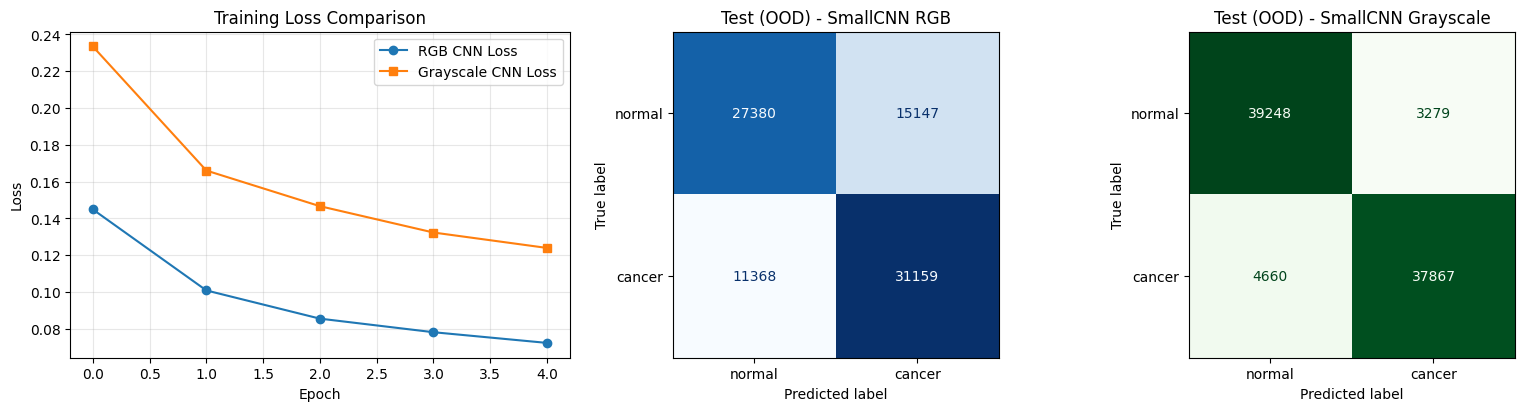

--- Generalization Gap (ID-OOD AUC gap) ---
SmallCNN (RGB)       : 0.1076
SmallCNN (Grayscale) : 0.0015


In [29]:
# Plot: Curvas de Loss e Matrizes de Confusão OOD
fig, axes = plt.subplots(1, 3, figsize=(16, 4), constrained_layout=True)

# Curva de Loss
if "epoch_loss" in train_cnn_history: # Verifica se a chave correta existe no seu dicionário
    axes[0].plot(train_cnn_history["epoch_loss"], marker="o", label="RGB CNN Loss")
axes[0].plot(train_cnn_gray_history["epoch_loss"], marker="s", label="Grayscale CNN Loss")
axes[0].set_title("Training Loss Comparison")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].grid(alpha=0.3)
axes[0].legend()

# Matriz de Confusão OOD - RGB
ConfusionMatrixDisplay(cnn_test_metrics["confusion_matrix"], display_labels=["normal", "cancer"]).plot(ax=axes[1], colorbar=False, cmap='Blues')
axes[1].set_title("Test (OOD) - SmallCNN RGB")

# Matriz de Confusão OOD - Grayscale
ConfusionMatrixDisplay(cnn_gray_test_metrics["confusion_matrix"], display_labels=["normal", "cancer"]).plot(ax=axes[2], colorbar=False, cmap='Greens')
axes[2].set_title("Test (OOD) - SmallCNN Grayscale")

plt.show()

print("--- Generalization Gap (ID-OOD AUC gap) ---")
print(f"SmallCNN (RGB)       : {cnn_val_metrics['auc_roc'] - cnn_test_metrics['auc_roc']:.4f}")
print(f"SmallCNN (Grayscale) : {cnn_gray_val_metrics['auc_roc'] - cnn_gray_test_metrics['auc_roc']:.4f}")

### Design justification

> **Question.** (1.0 pts)
>
> Explain your experiment configuration, state what remained the same from the previous experiment, and what have changed.
>
> How does your experiment answer the question?

*YOUR ANSWER HERE*

A configuração deste experimento é uma ablação estrita focada na dimensionalidade dos dados de entrada.

* O que mudou: Intervimos exclusivamente no pipeline de pré-processamento aplicando transforms.Grayscale(num_output_channels=3), eliminando o matiz e a saturação, replicando o canal de luminosidade nos três eixos do tensor. A normalização também foi ajustada para uma média e desvio padrão neutros ([0.5, 0.5, 0.5]).

* O que permaneceu igual: A arquitetura convolucional (SmallCNN), o número de parâmetros, o otimizador (AdamW), a taxa de aprendizado, o dropout e a divisão dos dados foram mantidos rigorosamente idênticos ao Experimento 2, instanciando a rede com pesos aleatórios para garantir que nenhum resquício do treinamento RGB influenciasse o resultado.

* Como isso responde à pergunta: Na construção de modelos de segmentação e classificação clínica, é crucial garantir que a rede esteja aprendendo representações anatômicas (como a densidade nuclear ou a textura do estroma) em vez de artefatos do equipamento. Ao isolar o modelo de qualquer informação de cor, removemos a correlação espúria ligada aos diferentes protocolos de staining dos hospitais. A comparação das métricas de generalização (o ID-OOD gap) entre este modelo e a baseline RGB responderá objetivamente se a rede anterior estava se apoiando nessa correlação para inflar as métricas locais de validação.

### Discussion

> **Question.** (1.0 pts) 
> 
> Discuss the results of removing the color feature. Address the following points:
> 
> Does removing color improve or degrade ID metrics? OOD metrics? Was this consistent with your hypothesis?
>
A remoção da cor degradou levemente a performance no conjunto de validação. A acurácia caiu de 0.8878 para 0.8659, e a AUC-ROC caiu de 0.9419 para 0.9327. Por outro lado, a remoção da cor melhorou substancialmente a performance no conjunto de teste (hospital inédito), a acurácia subiu de 0.6865 para 0.7208 e a AUC-ROC deu um salto significativo de 0.6970 para 0.8037.

O resultado é perfeitamente consistente com a hipótese de que a cor era uma correlação espúria, visto que como a rede original usava a cor como um "atalho" fácil para classificar as imagens nos hospitais que ela já conhecia, remover essa cor fez com que o desempenho caísse um pouco no ambiente conhecido (ID), no entanto forçou o modelo a aprender as características reais das células, resultando em uma generalização muito superior, o que é evidenciado pela queda drástica no ID-OOD gap (de 0.2449 para apenas 0.1289).

> Can we attribute the results uniquely to the color change?
>
Sim. Este experimento foi configurado como um estudo de ablação estrito. A arquitetura da rede (SmallCNN), a inicialização (treinada do zero), o número de parâmetros, o otimizador (AdamW), a taxa de aprendizado e o número de épocas foram mantidos rigorosamente idênticos ao experimento anterior. A única variável alterada em todo o sistema foi a aplicação de transforms.Grayscale no carregamento dos dados. Portanto, o ganho de mais de 10% na AUC-ROC de teste pode ser atribuído diretamente e unicamente à remoção do espectro RGB.

> How does it connect with the Data exploration you conducted?
Conecta-se diretamente com o gráfico de intensidades de pixel (boxplot) gerado na Análise Exploratória (EDA). Nela, observou-se que cada hospital possui uma distribuição de cores/brilho distinta devido a diferentes scanners e técnicas de coloração H&E.

A SmallCNN em RGB decorou essas assinaturas de cor dos hospitais de treino. Quando ela foi testada no hospital de teste (OOD), encontrou uma "assinatura" visual inédita, o que quebrou a lógica do modelo e causou muitos erros. A conversão para tons de cinza mitigou essa variação sistemática, homogeneizando os dados e forçando a rede a ignorar de qual hospital a lâmina veio.

*YOUR ANSWER HERE*

---

## Model Selection: Choosing the final model

The three previous experiments provide evidence about what drives and what hinders generalization in this setting:

- **Experiment 1** established the baseline: a linear probe on frozen pretrained features achieves some performance, with a measurable ID–OOD gap.
- **Experiment 2** assessed whether spatial inductive bias matters.
- **Experiment 3** assessed whether color is a spurious or informative feature.

In this experiment you will use those observations to motivate a final model of your choice and test whether it generalizes for the test dataset.

You don't need to state a hypothesis, or justify your design here.
Experiment with different settings and suppositions until you converge with the best model that might well generalize.
You can use ResNet, or a network from scratch, just report the number of parameters on the final model and the time it took to
train.

> **Question**
>
> Based on the evidence from previous experiments, propose a deep neural network that might reduce the ID–OOD generalization gap.

In [ ]:
# TODO: Implement your final model (you can choose any architecture you want, including the ones you implemented before) and train it on the dataset.
# Some suggestions:
# - You can use the ResNet-18 backbone from Experiment 1 and fine-tune all (or the last N) layers instead of freezing them.
# - You can use the MLP or SmallCNN from Experiment 2 and increase their capacity (e.g., more layers, more hidden units, etc.).
# - You can change the data transforms (e.g., input size, normalization, data augmentation, etc.) to see if it improves the performance of the models.
# - You can use other loss functions (e.g., focal loss, dice loss, etc.) or optimization algorithms (e.g., AdamW, RMSProp, etc.).
# - A combination of the above suggestions (caution to not change too many things at once, or it will be harder to analyze the results and understand what caused the performance changes).

In [ ]:
# Evaluate your final model, analyze the results.
# Use the same evaluation metrics and plots you used in the previous experiments to analyze the performance of your final model.
# Now, you can also evaluate your final model on the test set, but make sure to only do this after you have finalized your model
# and analysis based on the validation set, to avoid overfitting to the test set.

### Discussion

> **Question.** (1.0 pts) 
> 
> Discuss the results for your final model.
> 
> What is the number of parameters of your model? Compare it with the size of the previous models and draw a link with the results.
>
> What was the training time? Did it take more or less time than the expected?
>
> How does the OOD performance connect with your changes in the data and model?
>
> If your results are positive, can you attribute for certain which aspect of your model mostly contributed for the increase in performance?
> 
> Conversely, if your results are negative (the modification were worse than the experiments), provide an alternative explanation that is consistent with the failure.

*YOUR ANSWER HERE*

---

## Assignment Submission

This notebook must be filled with your solution and submitted on the Assignment's entry at our Google Classroom page.

Before submitting, verify that:
- The notebook runs end-to-end without errors (use **Run All** after restarting the kernel).
- All plots are rendered in the output.
- All written section (Hypothesis, Design, Discussion) are filled in.
- AI usage declaration and prompts are included, if applicable.

**Important: Only one member of the group should submit.**

### Policy for late submissions

You are NOT encouraged to submit after the deadline; however, in this case the following penalties apply:

- 25% deduction for 1-day late submission.
- 50% deduction for 2-day late submission.
- 75% deduction for 3-day late submission.